# Laptop Pricing & Market Trend Analysis

## 1. Problem Definition

Laptop buyers face confusion due to:
* Too many available models
* Similar specifications
* Large price differences
* Brand influence

Even when laptops have similar RAM, storage, and processor types, their prices vary significantly. This makes it difficult for customers to identify the best value-for-money option.

## 2. Business Problem Statement

The laptop market contains numerous options with overlapping features but inconsistent pricing.

The goal of this project is to analyze laptop data using Exploratory Data Analysis (EDA) to:
* Understand pricing patterns
* Identify key features affecting price
* Detect brand-based premium pricing
* Help customers make informed decisions

## 3. Project Objectives
* Identify important price-driving features
* Compare impact of RAM, SSD, and Processor on price
* Analyze brand influence on pricing
* Study relationship between rating and price
* Identify best value configurations
* Provide data-driven recommendations

In [1]:
import pandas as pd
import numpy as np
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
options = Options()
options.add_argument('--start-maximized')

service = Service(ChromeDriverManager().install())

driver = webdriver.Chrome(service=service, options=options)

In [109]:
url='https://www.flipkart.com/'

In [110]:
driver.get(url)

In [111]:
search_box = driver.find_element(By.XPATH, '//*[@id="container"]/div/div[1]/div/div/div/div/div/div/div/div/div/div[1]/div[2]/div/div/div[2]/div/div/div/div/div/header/div[1]/div[1]/form/div/div/input')
search_box.send_keys('laptop')
search_box.send_keys(Keys.RETURN)

In [8]:
page_length = driver.execute_script('return document.body.scrollHeight')
page_length

8831

In [9]:
a = driver.find_elements(By.CLASS_NAME, "RG5Slk")
a

[<selenium.webdriver.remote.webelement.WebElement (session="0abfa33d40d9b86c07c0d9c2662694b6", element="f.C5A74394742788CE70005B9CC70423A3.d.B33358A8F60911FF1513D79D61A408F0.e.140")>,
 <selenium.webdriver.remote.webelement.WebElement (session="0abfa33d40d9b86c07c0d9c2662694b6", element="f.C5A74394742788CE70005B9CC70423A3.d.B33358A8F60911FF1513D79D61A408F0.e.141")>,
 <selenium.webdriver.remote.webelement.WebElement (session="0abfa33d40d9b86c07c0d9c2662694b6", element="f.C5A74394742788CE70005B9CC70423A3.d.B33358A8F60911FF1513D79D61A408F0.e.142")>,
 <selenium.webdriver.remote.webelement.WebElement (session="0abfa33d40d9b86c07c0d9c2662694b6", element="f.C5A74394742788CE70005B9CC70423A3.d.B33358A8F60911FF1513D79D61A408F0.e.143")>,
 <selenium.webdriver.remote.webelement.WebElement (session="0abfa33d40d9b86c07c0d9c2662694b6", element="f.C5A74394742788CE70005B9CC70423A3.d.B33358A8F60911FF1513D79D61A408F0.e.144")>,
 <selenium.webdriver.remote.webelement.WebElement (session="0abfa33d40d9b86c07c0

In [10]:
Brand = []

for i in driver.find_elements(By.CLASS_NAME, "RG5Slk"):
    text = i.text
    a = re.findall('^(\w+)', text)
    if a:
        Brand.extend(a)
    else:
        Brand.append(np.nan)

print(Brand)
print(len(Brand))

['DELL', 'DELL', 'ASUS', 'Lenovo', 'Acer', 'ASUS', 'ASUS', 'ASUS', 'Acer', 'ASUS', 'DELL', 'DELL', 'HP', 'ASUS', 'HP', 'ASUS', 'DELL', 'ASUS', 'Acer', 'ASUS', 'DELL', 'Lenovo', 'Lenovo', 'Samsung']
24


In [11]:
Processor = []
for i in driver.find_elements(By.CLASS_NAME, 'HwRTzP'):
    text = i.text
    a = re.findall('(.+)\s+Processor', text)
    if a:
        Processor.extend(a)
    else:
        Processor.append(np.nan)
    
print(Processor)
print(len(Processor))

['Intel Core Ultra 5', 'Snapdragon X', 'Intel Core i3', 'MediaTek Kompanio 520', 'Intel Core i3', 'Intel Core 5', 'AMD Ryzen 5 Quad Core', 'Intel Core i3', 'AMD Ryzen 7 Octa Core', 'AMD Ryzen 3 Quad Core', 'Intel Core i5', 'Intel Core i5', 'Intel Celeron Dual Core', 'Intel Celeron Dual Core', 'Intel Core i5', 'AMD Ryzen 5 Quad Core', 'Intel Core i5', 'Intel Core 7', 'Intel Celeron Dual Core', 'Intel Celeron Dual Core', 'Intel Core Ultra 5', 'AMD Ryzen 7 Octa Core', 'AMD Ryzen 5 Hexa Core', 'Intel Core i5']
24


In [12]:
Selling_Price = []

products = driver.find_elements(By.CLASS_NAME, 'k7wcnx')

for product in products:
    tags = product.find_elements(By.CSS_SELECTOR, '.hZ3P6w.DeU9vF')
    if tags:
        text = tags[0].text
        a = re.findall(r'[\d,]+', text)
        if a:
            Selling_Price.append(a[0])
        else:
            Selling_Price.append(np.nan)
    else:
        Selling_Price.append(np.nan)

print(Selling_Price)
print(len(Selling_Price))

['77,990', '60,990', '40,990', '14,999', '38,938', '64,990', '38,990', '40,990', '46,990', '35,990', '78,990', '56,990', '29,990', '19,714', '51,990', '44,590', '50,490', '76,990', '25,990', '18,799', '90,490', '1,15,990', '42,990', '59,990']
24


In [13]:
Original_Price = []

products = driver.find_elements(By.CLASS_NAME, 'k7wcnx')

for product in products:
    tags = product.find_elements(By.CSS_SELECTOR, '.kRYCnD.gxR4EY')
    if tags:
        text = tags[0].text
        a = re.findall(r'[\d,]+', text)
        if a:
            Original_Price.append(a[0])
        else:
            Original_Price.append(np.nan)
    else:
        Original_Price.append(np.nan)

print(Original_Price)
print(len(Original_Price))

['98,040', '87,704', '50,990', '16,298', '42,990', '89,990', '50,990', '50,990', '72,999', '43,990', '1,01,709', '64,874', '31,933', '23,900', '68,417', '55,990', '63,416', '99,990', '35,999', '21,990', '1,02,656', '1,32,590', '59,090', '82,789']
24


In [14]:
Discount_on_OriginalPrice = []

products = driver.find_elements(By.CLASS_NAME, 'k7wcnx') 

for product in products:
    tags = product.find_elements(By.CLASS_NAME, 'HQe8jr')
    
    if tags:
        text = tags[0].text
        a = re.findall('(.+)\%', text)
        Discount_on_OriginalPrice.append(a[0])
    else:
        Discount_on_OriginalPrice.append(np.nan)

print(Discount_on_OriginalPrice)
print(len(Discount_on_OriginalPrice))

['20', '30', '19', '7', '9', '27', '23', '19', '35', '18', '22', '12', '6', '17', '24', '20', '20', '23', '27', '14', '11', '12', '27', '27']
24


In [15]:
Rating = []
products = driver.find_elements(By.CLASS_NAME, 'k7wcnx') 

for product in products:
    # checks for the rating tag inside the product
    tag = product.find_elements(By.CLASS_NAME, 'CjyrHS')
    
    if tag:
        # Extract numbers from the tag text
        text = tag[0].text
        a = re.findall('\d+\.\d+|\d+', text)
        
        # If a number is found, add it. Otherwise, add nan.
        if a:
            Rating.append(a[0])
        else:
            Rating.append(np.nan)
    else:
        # If the tag doesn't exist at all, add nan
        Rating.append(np.nan)

print(Rating)
print(len(Rating))

['4.3', nan, '4.3', '4', '4', '4.2', '4.3', '4.3', '4.1', '4.3', '4.2', '4.3', '3.7', '3.8', '4.2', '4.3', '4.2', '4.2', '3.8', '3.8', '4.3', '4.3', '4.6', '4.4']
24


In [16]:
SSD = []

products = driver.find_elements(By.CLASS_NAME, 'CMXw7N') 

for product in products:
    text = product.text
    a = re.findall('(\d+\s?(?:GB|TB))\s?SSD', text)
    
    if a:
        SSD.extend(a)
    else:
        SSD.append(np.nan)

print(SSD)
print(len(SSD))

['512 GB', '512 GB', '512 GB', nan, '512 GB', '512 GB', '512 GB', '512 GB', '512 GB', '512 GB', '1 TB', '512 GB', '512 GB', nan, '512 GB', '512 GB', '512 GB', '512 GB', '512 GB', nan, '512 GB', '1 TB', '512 GB', '512 GB']
24


In [17]:
RAM = []

products = driver.find_elements(By.CLASS_NAME, 'CMXw7N') 

for product in products:
    text = product.text
    a = re.findall('(\d+)\s*GB.*?RAM', text)
    if a:
        RAM.extend(a)
    else:
        RAM.append(np.nan)

print(RAM)
print(len(RAM))

['16', '16', '8', '4', '8', '16', '8', '8', '16', '8', '16', '16', '8', '4', '12', '16', '8', '16', '8', '4', '16', '24', '16', '16']
24


In [18]:
RAM_TYPE = []

for i in driver.find_elements(By.CLASS_NAME, 'CMXw7N'):
    text = i.text
    a = re.findall('GB\s(.+)\s+RAM', text)
    if a:
        RAM_TYPE.extend(a)
    else:
        RAM_TYPE.append(np.nan)

print(RAM_TYPE)
print(len(RAM_TYPE))

['LPDDR5X', 'LPDDR5X', 'DDR4', 'LPDDR4X', 'DDR4', 'DDR5', 'LPDDR5', 'DDR4', 'DDR4', 'LPDDR5', 'DDR5', 'DDR4', 'DDR4', 'LPDDR4X', 'DDR4', 'LPDDR5', 'DDR4', 'DDR5', 'DDR4', 'LPDDR4X', 'LPDDR5X', 'DDR5', 'DDR4', 'LPDDR4X']
24


In [19]:
OS = []

for i in driver.find_elements(By.CLASS_NAME, 'CMXw7N'):
    text = i.text
    a = re.findall('(.+?)\s*Operating System', text)
    if a:
        OS.extend(a)
    else:
        OS.append(np.nan)
    
print(OS)
print(len(OS))

['Windows 11 Home', 'Windows 11 Home', 'Windows 11 Home', 'Chrome', '64 bit Windows 11 Home', '64 bit Windows 11 Home', 'Windows 11 Home', 'Windows 11', 'Windows 11', 'Windows 11 Home', 'Windows 11', 'Windows 11', 'Windows 11 Home', 'Chrome', 'Windows 11 Home', 'Windows 11 Home', '64 bit Windows 11', '64 bit Windows 11 Home', '64 bit Windows 11 Home', 'Chrome', 'Windows 11', 'Windows 11 Home', 'Windows 11 Home', 'Windows 11']
24


In [20]:
Display = []

for i in driver.find_elements(By.CLASS_NAME,'CMXw7N'):
    text = i.text
    a = re.findall('(\d+\.?\d*)[^a-zA-Z]*[Ii]nch',text)
    if a:
        Display.extend(a)
    else:
        Display.append(np.nan)
    
print(Display)
print(len(Display))

['14', '14', '14', '11.6', '15.6', '15.6', '15.6', '15.6', '15.6', '15.6', '15.6', '15.6', '14', '14', '15.6', '15.6', '15.6', '15.6', '11.6', '14', '14', '15.6', '15.6', '15.6']
24


In [21]:
from itertools import zip_longest

data = list(zip(Brand, Processor, Selling_Price, Original_Price, Discount_on_OriginalPrice, Rating, SSD, RAM, RAM_TYPE, OS, Display))
data 

[('DELL',
  'Intel Core Ultra 5',
  '77,990',
  '98,040',
  '20',
  '4.3',
  '512 GB',
  '16',
  'LPDDR5X',
  'Windows 11 Home',
  '14'),
 ('DELL',
  'Snapdragon X',
  '60,990',
  '87,704',
  '30',
  nan,
  '512 GB',
  '16',
  'LPDDR5X',
  'Windows 11 Home',
  '14'),
 ('ASUS',
  'Intel Core i3',
  '40,990',
  '50,990',
  '19',
  '4.3',
  '512 GB',
  '8',
  'DDR4',
  'Windows 11 Home',
  '14'),
 ('Lenovo',
  'MediaTek Kompanio 520',
  '14,999',
  '16,298',
  '7',
  '4',
  nan,
  '4',
  'LPDDR4X',
  'Chrome',
  '11.6'),
 ('Acer',
  'Intel Core i3',
  '38,938',
  '42,990',
  '9',
  '4',
  '512 GB',
  '8',
  'DDR4',
  '64 bit Windows 11 Home',
  '15.6'),
 ('ASUS',
  'Intel Core 5',
  '64,990',
  '89,990',
  '27',
  '4.2',
  '512 GB',
  '16',
  'DDR5',
  '64 bit Windows 11 Home',
  '15.6'),
 ('ASUS',
  'AMD Ryzen 5 Quad Core',
  '38,990',
  '50,990',
  '23',
  '4.3',
  '512 GB',
  '8',
  'LPDDR5',
  'Windows 11 Home',
  '15.6'),
 ('ASUS',
  'Intel Core i3',
  '40,990',
  '50,990',
  '19',
 

In [22]:
df = pd.DataFrame(data, columns = ['Brand', 'Processor', 'Selling_Price', 'Original_Price', 'Discount_on_OrginalPrice', 'Rating', 'SSD', 'RAM', 'RAM_TYPE', 'OS', 'Display'])
df

,Brand,Processor,Selling_Price,Original_Price,Discount_on_OrginalPrice,Rating,SSD,RAM,RAM_TYPE,OS,Display
0,DELL,Intel Core Ultra 5,"77,990","98,040",20,4.3,512 GB,16,LPDDR5X,Windows 11 Home,14
1,DELL,Snapdragon X,"60,990","87,704",30,NaN,512 GB,16,LPDDR5X,Windows 11 Home,14
2,ASUS,Intel Core i3,"40,990","50,990",19,4.3,512 GB,8,DDR4,Windows 11 Home,14
3,Lenovo,MediaTek Kompanio 520,"14,999","16,298",7,4,NaN,4,LPDDR4X,Chrome,11.6
4,Acer,Intel Core i3,"38,938","42,990",9,4,512 GB,8,DDR4,64 bit Windows 11 Home,15.6
5,ASUS,Intel Core 5,"64,990","89,990",27,4.2,512 GB,16,DDR5,64 bit Windows 11 Home,15.6
6,ASUS,AMD Ryzen 5 Quad Core,"38,990","50,990",23,4.3,512 GB,8,LPDDR5,Windows 11 Home,15.6
7,ASUS,Intel Core i3,"40,990","50,990",19,4.3,512 GB,8,DDR4,Windows 11,15.6
8,Acer,AMD Ryzen 7 Octa Core,"46,990","72,999",35,4.1,512 GB,16,DDR4,Windows 11,15.6
9,ASUS,AMD Ryzen 3 Quad Core,"35,990","43,990",18,4.3,512 GB,8,LPDDR5,Windows 11 Home,15.6


In [23]:
import time

Brand = []
Processor = []
Selling_Price = []
Original_Price = []
Discount_on_OriginalPrice = []
Rating = []
SSD = []
RAM = []
RAM_TYPE = []
OS = []
Display = []

for page in range(1,43):
    url=f'https://www.flipkart.com/search?q=laptop&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={page}'
    driver.get(url)
    time.sleep(2)

    brand_element = driver.find_elements(By.CLASS_NAME, "RG5Slk")
    for i in brand_element:
        text = i.text
        a = re.findall('^(\w+)', text)
        if a:
            Brand.extend(a)
        else:
            Brand.append(np.nan)

    
    processor_element = driver.find_elements(By.CLASS_NAME, 'HwRTzP')
    for i in processor_element:
        text = i.text
        a = re.findall('(.+)\s+Processor', text)
        if a:
            Processor.extend(a)
        else:
            Processor.append(np.nan)    

    
    selling_price_element = driver.find_elements(By.CLASS_NAME, 'k7wcnx')
    for product in selling_price_element:
        tags = product.find_elements(By.CSS_SELECTOR, '.hZ3P6w.DeU9vF')
        if tags:
            text = tags[0].text
            a = re.findall('[\d,]+', text)
            if a:
                Selling_Price.append(a[0])
            else:
                Selling_Price.append(np.nan)
        else:
            Selling_Price.append(np.nan)

            
    original_price_element = driver.find_elements(By.CLASS_NAME, 'k7wcnx')
    for product in original_price_element:
        tags = product.find_elements(By.CSS_SELECTOR, '.kRYCnD.gxR4EY')
        if tags:
            text = tags[0].text
            a = re.findall('[\d,]+', text)
            if a:
                Original_Price.append(a[0])
            else:
                Original_Price.append(np.nan)
        else:
            Original_Price.append(np.nan)

    
    discount_on_originalprice_element = driver.find_elements(By.CLASS_NAME, 'k7wcnx') 
    for product in discount_on_originalprice_element:
        tags = product.find_elements(By.CLASS_NAME, 'HQe8jr')
        if tags:
            text = tags[0].text
            a = re.findall('(.+)\%', text)
            Discount_on_OriginalPrice.append(a[0])
        else:
            Discount_on_OriginalPrice.append(np.nan)

    
    rating_element = driver.find_elements(By.CLASS_NAME, 'k7wcnx') 
    for product in rating_element:
        tag = product.find_elements(By.CLASS_NAME, 'CjyrHS')
        if tag:
            text = tag[0].text
            a = re.findall('\d+\.\d+|\d+', text)
            if a:
                Rating.append(a[0])
            else:
                Rating.append(np.nan)
        else:
            Rating.append(np.nan)
    
    
    ssd_element = driver.find_elements(By.CLASS_NAME, 'CMXw7N')
    for product in ssd_element:
        text = product.text
        a = re.findall('(\d+\s?(?:GB|TB))\s?SSD', text)
        if a:
            SSD.extend(a)
        else:
            SSD.append(np.nan)

    
    ram_element = driver.find_elements(By.CLASS_NAME, 'CMXw7N')
    for i in ram_element:
        text = i.text
        a = re.findall('(\d+)\s*GB.*?RAM', text)
        if a:
            RAM.extend(a)
        else:
            RAM.append(np.nan)

    
    ram_type_element = driver.find_elements(By.CLASS_NAME, 'CMXw7N')
    for i in ram_type_element:
        text = i.text
        a = re.findall('GB\s(.+)\s+RAM', text)
        if a:
            RAM_TYPE.extend(a)
        else:
            RAM_TYPE.append(np.nan)
            

    os_element = driver.find_elements(By.CLASS_NAME, 'CMXw7N')
    for i in os_element:
        text = i.text
        a = re.findall('(.+?)\s*Operating System', text)
        if a:
            OS.extend(a)
        else:
            OS.append(np.nan)
            

    display_element = driver.find_elements(By.CLASS_NAME,'CMXw7N')
    for i in display_element:
        text = i.text
        a = re.findall('(\d+\.?\d*)[^a-zA-Z]*[Ii]nch',text)
        if a:
            Display.extend(a)
        else:
            Display.append(np.nan)
    
    print(f'Page {page} scraped')

Page 1 scraped
Page 2 scraped
Page 3 scraped
Page 4 scraped
Page 5 scraped
Page 6 scraped
Page 7 scraped
Page 8 scraped
Page 9 scraped
Page 10 scraped
Page 11 scraped
Page 12 scraped
Page 13 scraped
Page 14 scraped
Page 15 scraped
Page 16 scraped
Page 17 scraped
Page 18 scraped
Page 19 scraped
Page 20 scraped
Page 21 scraped
Page 22 scraped
Page 23 scraped
Page 24 scraped
Page 25 scraped
Page 26 scraped
Page 27 scraped
Page 28 scraped
Page 29 scraped
Page 30 scraped
Page 31 scraped
Page 32 scraped
Page 33 scraped
Page 34 scraped
Page 35 scraped
Page 36 scraped
Page 37 scraped
Page 38 scraped
Page 39 scraped
Page 40 scraped
Page 41 scraped
Page 42 scraped


In [24]:
print(Brand, Processor, Selling_Price, Original_Price, Discount_on_OriginalPrice, Rating, SSD, RAM, RAM_TYPE, OS, Display)

['DELL', 'DELL', 'ASUS', 'Lenovo', 'Acer', 'ASUS', 'ASUS', 'ASUS', 'Acer', 'ASUS', 'DELL', 'DELL', 'HP', 'ASUS', 'HP', 'ASUS', 'DELL', 'ASUS', 'Acer', 'ASUS', 'DELL', 'Lenovo', 'Lenovo', 'Samsung', 'Acer', 'Lenovo', 'ASUS', 'DELL', 'DELL', 'Acer', 'DELL', 'DELL', 'ASUS', 'ASUS', 'Acer', 'HP', 'DELL', 'DELL', 'Acer', 'ASUS', 'ASUS', 'DELL', 'DELL', 'Acer', 'ASUS', 'HP', 'Lenovo', 'DELL', 'Acer', 'Acer', 'ASUS', 'DELL', 'Lenovo', 'ASUS', 'ASUS', 'ASUS', 'DELL', 'DELL', 'HP', 'ASUS', 'DELL', 'DELL', 'Samsung', 'ASUS', 'Lenovo', 'ASUS', 'ASUS', 'DELL', 'HP', 'Lenovo', 'Lenovo', 'DELL', 'Acer', 'Lenovo', 'Lenovo', 'Primebook', 'ASUS', 'DELL', 'ASUS', 'Acer', 'DELL', 'DELL', 'HP', 'Acer', 'HP', 'Acer', 'DELL', 'DELL', 'ASUS', 'ASUS', 'ASUS', 'DELL', 'Ultimus', 'Lenovo', 'ASUS', 'DELL', 'ASUS', 'DELL', 'Lenovo', 'ASUS', 'DELL', 'DELL', 'DELL', 'ASUS', 'HP', 'Acer', 'DELL', 'DELL', 'DELL', 'MSI', 'ASUS', 'DELL', 'Lenovo', 'ASUS', 'ASUS', 'Lenovo', 'Lenovo', 'DELL', 'Lenovo', 'Acer', 'ASUS', 'D

In [25]:
data = list(zip(Brand, Processor, OS, RAM, RAM_TYPE, SSD, Display, Selling_Price, Original_Price, Discount_on_OriginalPrice, Rating))
data

[('DELL',
  'Intel Core Ultra 5',
  'Windows 11 Home',
  '16',
  'LPDDR5X',
  '512 GB',
  '14',
  '77,990',
  '98,040',
  '20',
  '4.3'),
 ('DELL',
  'Snapdragon X',
  'Windows 11 Home',
  '16',
  'LPDDR5X',
  '512 GB',
  '14',
  '60,990',
  '87,704',
  '30',
  nan),
 ('ASUS',
  'Intel Core i3',
  'Windows 11 Home',
  '8',
  'DDR4',
  '512 GB',
  '14',
  '40,990',
  '50,990',
  '19',
  '4.3'),
 ('Lenovo',
  'MediaTek Kompanio 520',
  'Chrome',
  '4',
  'LPDDR4X',
  nan,
  '11.6',
  '14,999',
  '16,298',
  '7',
  '4'),
 ('Acer',
  'Intel Core i3',
  '64 bit Windows 11 Home',
  '8',
  'DDR4',
  '512 GB',
  '15.6',
  '38,938',
  '42,990',
  '9',
  '4'),
 ('ASUS',
  'Intel Core 5',
  '64 bit Windows 11 Home',
  '16',
  'DDR5',
  '512 GB',
  '15.6',
  '64,990',
  '89,990',
  '27',
  '4.2'),
 ('ASUS',
  'AMD Ryzen 5 Quad Core',
  'Windows 11 Home',
  '8',
  'LPDDR5',
  '512 GB',
  '15.6',
  '38,990',
  '50,990',
  '23',
  '4.3'),
 ('ASUS',
  'Intel Core i3',
  'Windows 11',
  '8',
  'DDR4',


In [26]:
df = pd.DataFrame(data,columns=['Brand', 'Processor', 'OS', 'RAM', 'RAM_Type', 'SSD', 'Display', 'Selling_Price', 'Original_Price', 'Discount_on_OriginalPrice', 'Rating'])
df

,Brand,Processor,OS,RAM,RAM_Type,SSD,Display,Selling_Price,Original_Price,Discount_on_OriginalPrice,Rating
0,DELL,Intel Core Ultra 5,Windows 11 Home,16,LPDDR5X,512 GB,14,"77,990","98,040",20,4.3
1,DELL,Snapdragon X,Windows 11 Home,16,LPDDR5X,512 GB,14,"60,990","87,704",30,NaN
2,ASUS,Intel Core i3,Windows 11 Home,8,DDR4,512 GB,14,"40,990","50,990",19,4.3
3,Lenovo,MediaTek Kompanio 520,Chrome,4,LPDDR4X,NaN,11.6,"14,999","16,298",7,4
4,Acer,Intel Core i3,64 bit Windows 11 Home,8,DDR4,512 GB,15.6,"38,938","42,990",9,4
...,...,...,...,...,...,...,...,...,...,...,...
979,HP,Intel Core i5,64 bit Windows 11,16,DDR4,512 GB,15.6,"54,143","62,990",14,4.3
980,DELL,Intel Core Ultra 5,Windows 11,16,LPDDR5X,512 GB,14,"90,490","1,02,656",11,4.3
981,DELL,Intel Core i7,Windows 11,16,DDR4,512 GB,15.6,"68,990","73,911",6,4.3
982,DELL,Intel Core i5,Linux/Ubuntu,16,DDR4,512 GB,14,"59,989","79,990",25,3.7


In [27]:
df.to_csv(r"D:\Web Scraping\Laptop Data.csv", index = False)

## Importing Data

In [2]:
import pandas as pd
df = pd.read_csv('Laptop Data.csv')

In [3]:
df

,Brand,Processor,OS,RAM,RAM_Type,SSD,Display,Selling_Price,Original_Price,Discount_on_OriginalPrice,Rating
0,DELL,Intel Core Ultra 5,Windows 11 Home,16,LPDDR5X,512 GB,14.0,"77,990","98,040",20.0,4.3
1,DELL,Snapdragon X,Windows 11 Home,16,LPDDR5X,512 GB,14.0,"60,990","87,704",30.0,NaN
2,ASUS,Intel Core i3,Windows 11 Home,8,DDR4,512 GB,14.0,"40,990","50,990",19.0,4.3
3,Lenovo,MediaTek Kompanio 520,Chrome,4,LPDDR4X,NaN,11.6,"14,999","16,298",7.0,4.0
4,Acer,Intel Core i3,64 bit Windows 11 Home,8,DDR4,512 GB,15.6,"38,938","42,990",9.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
979,HP,Intel Core i5,64 bit Windows 11,16,DDR4,512 GB,15.6,"54,143","62,990",14.0,4.3
980,DELL,Intel Core Ultra 5,Windows 11,16,LPDDR5X,512 GB,14.0,"90,490","1,02,656",11.0,4.3
981,DELL,Intel Core i7,Windows 11,16,DDR4,512 GB,15.6,"68,990","73,911",6.0,4.3
982,DELL,Intel Core i5,Linux/Ubuntu,16,DDR4,512 GB,14.0,"59,989","79,990",25.0,3.7


## Data Understanding

* Dataset contains laptop listings scraped from Flipkart.
* Each row represents one laptop model/variant.
* Columns represent price, hardware specifications, and performance details.

### Key Columns
* **Brand** :- Manufacturer of the laptop (HP, ASUS, Lenovo, Dell, Acer, etc.)
* **Processor** :– CPU type and generation (e.g., Intel Core i5, Ryzen 7, etc.). Represents performance capability.
* **Selling_Price** :- Current selling price of the laptop.
* **Original_Price** :- Original listed price before discount(MRP before discount).
* **Discount_on_Original_Price** :- Percentage discount offered.
* **Rating** :- Customer rating score out of 5. Represents user satisfaction.
* **SSD** :- Storage capacity in GB/TB. Affects speed and storage space.
* **RAM** :- Memory size in GB. Higher RAM improves multitasking performance.
* **Ram_Type** :– DDR version (DDR4, DDR5, etc.)
* **OS** :- Operating System installed (Windows, Linux, Chrome, etc.)
* **Display** :- Screen size in inches. Important factor for usability and portability.

In [4]:
df.head()

,Brand,Processor,OS,RAM,RAM_Type,SSD,Display,Selling_Price,Original_Price,Discount_on_OriginalPrice,Rating
0,DELL,Intel Core Ultra 5,Windows 11 Home,16,LPDDR5X,512 GB,14.0,"77,990","98,040",20.0,4.3
1,DELL,Snapdragon X,Windows 11 Home,16,LPDDR5X,512 GB,14.0,"60,990","87,704",30.0,NaN
2,ASUS,Intel Core i3,Windows 11 Home,8,DDR4,512 GB,14.0,"40,990","50,990",19.0,4.3
3,Lenovo,MediaTek Kompanio 520,Chrome,4,LPDDR4X,NaN,11.6,"14,999","16,298",7.0,4.0
4,Acer,Intel Core i3,64 bit Windows 11 Home,8,DDR4,512 GB,15.6,"38,938","42,990",9.0,4.0


In [5]:
df.tail()

,Brand,Processor,OS,RAM,RAM_Type,SSD,Display,Selling_Price,Original_Price,Discount_on_OriginalPrice,Rating
979,HP,Intel Core i5,64 bit Windows 11,16,DDR4,512 GB,15.6,"54,143","62,990",14.0,4.3
980,DELL,Intel Core Ultra 5,Windows 11,16,LPDDR5X,512 GB,14.0,"90,490","1,02,656",11.0,4.3
981,DELL,Intel Core i7,Windows 11,16,DDR4,512 GB,15.6,"68,990","73,911",6.0,4.3
982,DELL,Intel Core i5,Linux/Ubuntu,16,DDR4,512 GB,14.0,"59,989","79,990",25.0,3.7
983,HP,Intel Core i5,Windows 11 Home,8,DDR4,512 GB,15.6,"74,990","78,500",4.0,3.6


In [6]:
df.shape

(984, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Brand                      984 non-null    object 
 1   Processor                  984 non-null    object 
 2   OS                         984 non-null    object 
 3   RAM                        984 non-null    int64  
 4   RAM_Type                   984 non-null    object 
 5   SSD                        955 non-null    object 
 6   Display                    983 non-null    float64
 7   Selling_Price              984 non-null    object 
 8   Original_Price             957 non-null    object 
 9   Discount_on_OriginalPrice  949 non-null    float64
 10  Rating                     866 non-null    float64
dtypes: float64(3), int64(1), object(7)
memory usage: 84.7+ KB


## Check Missing Values

In [8]:
df.isna().sum()

Brand                          0
Processor                      0
OS                             0
RAM                            0
RAM_Type                       0
SSD                           29
Display                        1
Selling_Price                  0
Original_Price                27
Discount_on_OriginalPrice     35
Rating                       118
dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RAM,984.0,14.522358,5.179142,4.0,8.0,16.0,16.0,36.0
Display,983.0,14.948118,0.966187,7.0,14.0,15.6,15.6,17.3
Discount_on_OriginalPrice,949.0,21.616438,9.950107,1.0,12.0,21.0,28.0,55.0
Rating,866.0,4.248961,0.266781,2.3,4.2,4.3,4.3,5.0


In [10]:
df.describe(include='object')

,Brand,Processor,OS,RAM_Type,SSD,Selling_Price,Original_Price
count,984,984,984,984,955,984,957
unique,19,48,13,9,6,315,326
top,DELL,Intel Core i5,Windows 11,DDR4,512 GB,"64,990","89,990"
freq,327,259,384,353,752,46,48


## Fixing Data Types

In [11]:
df.dtypes

Brand                         object
Processor                     object
OS                            object
RAM                            int64
RAM_Type                      object
SSD                           object
Display                      float64
Selling_Price                 object
Original_Price                object
Discount_on_OriginalPrice    float64
Rating                       float64
dtype: object

#### Removing commas from price columns

In [12]:
df['Selling_Price'] = df['Selling_Price'].str.replace(',', '')
df['Original_Price'] = df['Original_Price'].str.replace(',', '')

#### Converting price columns to numeric

In [13]:
df['Selling_Price'] = pd.to_numeric(df['Selling_Price'])
df['Original_Price'] = pd.to_numeric(df['Original_Price'])

In [14]:
df.dtypes

Brand                         object
Processor                     object
OS                            object
RAM                            int64
RAM_Type                      object
SSD                           object
Display                      float64
Selling_Price                  int64
Original_Price               float64
Discount_on_OriginalPrice    float64
Rating                       float64
dtype: object

In [15]:
df.head()

,Brand,Processor,OS,RAM,RAM_Type,SSD,Display,Selling_Price,Original_Price,Discount_on_OriginalPrice,Rating
0,DELL,Intel Core Ultra 5,Windows 11 Home,16,LPDDR5X,512 GB,14.0,77990,98040.0,20.0,4.3
1,DELL,Snapdragon X,Windows 11 Home,16,LPDDR5X,512 GB,14.0,60990,87704.0,30.0,NaN
2,ASUS,Intel Core i3,Windows 11 Home,8,DDR4,512 GB,14.0,40990,50990.0,19.0,4.3
3,Lenovo,MediaTek Kompanio 520,Chrome,4,LPDDR4X,NaN,11.6,14999,16298.0,7.0,4.0
4,Acer,Intel Core i3,64 bit Windows 11 Home,8,DDR4,512 GB,15.6,38938,42990.0,9.0,4.0


## Clean SSD Column

In [16]:
# Extract Number from SSD and converting it into Numeric

df['SSD_Value'] = df['SSD'].str.extract('(\d+)')
df['SSD_Value'] = pd.to_numeric(df['SSD_Value'])

In [17]:
df.dtypes

Brand                         object
Processor                     object
OS                            object
RAM                            int64
RAM_Type                      object
SSD                           object
Display                      float64
Selling_Price                  int64
Original_Price               float64
Discount_on_OriginalPrice    float64
Rating                       float64
SSD_Value                    float64
dtype: object

In [18]:
# Extract Unit (GB or TB)

df['SSD_Unit'] = df['SSD'].str.extract('(TB|GB)')

In [19]:
# Convert TB to GB

df.loc[df['SSD_Unit'] == 'TB', 'SSD_Value'] = df['SSD_Value'] * 1024

In [20]:
# Create Final SSD_GB Column

df['SSD_GB'] = df['SSD_Value']

### Drop Unwanted Columns

In [21]:
df.drop(['SSD', 'SSD_Value', 'SSD_Unit'], axis=1, inplace=True)

In [22]:
df.head()

,Brand,Processor,OS,RAM,RAM_Type,Display,Selling_Price,Original_Price,Discount_on_OriginalPrice,Rating,SSD_GB
0,DELL,Intel Core Ultra 5,Windows 11 Home,16,LPDDR5X,14.0,77990,98040.0,20.0,4.3,512.0
1,DELL,Snapdragon X,Windows 11 Home,16,LPDDR5X,14.0,60990,87704.0,30.0,NaN,512.0
2,ASUS,Intel Core i3,Windows 11 Home,8,DDR4,14.0,40990,50990.0,19.0,4.3,512.0
3,Lenovo,MediaTek Kompanio 520,Chrome,4,LPDDR4X,11.6,14999,16298.0,7.0,4.0,NaN
4,Acer,Intel Core i3,64 bit Windows 11 Home,8,DDR4,15.6,38938,42990.0,9.0,4.0,512.0


In [23]:
df.dtypes

Brand                         object
Processor                     object
OS                            object
RAM                            int64
RAM_Type                      object
Display                      float64
Selling_Price                  int64
Original_Price               float64
Discount_on_OriginalPrice    float64
Rating                       float64
SSD_GB                       float64
dtype: object

## Duplicates

In [24]:
df[df.duplicated()]

,Brand,Processor,OS,RAM,RAM_Type,Display,Selling_Price,Original_Price,Discount_on_OriginalPrice,Rating,SSD_GB
26,ASUS,Intel Core 5,64 bit Windows 11 Home,16,DDR5,15.6,64990,89990.0,27.0,4.2,512.0
27,DELL,Intel Core Ultra 5,Windows 11 Home,16,LPDDR5X,14.0,77990,98040.0,20.0,4.3,512.0
30,DELL,Intel Core i5,Windows 11,16,DDR5,15.6,78990,101709.0,22.0,4.2,1024.0
31,DELL,Snapdragon X,Windows 11 Home,16,LPDDR5X,14.0,60990,87704.0,30.0,NaN,512.0
36,DELL,Intel Core i5,Windows 11,16,DDR4,15.6,56990,64874.0,12.0,4.3,512.0
...,...,...,...,...,...,...,...,...,...,...,...
971,DELL,Intel Core i5,Windows 11,16,DDR4,15.6,56990,64874.0,12.0,4.3,512.0
976,ASUS,Intel Core 7,64 bit Windows 11 Home,16,DDR5,15.6,76990,99990.0,23.0,4.2,512.0
977,DELL,Intel Core Ultra 7,Windows 11,16,LPDDR5X,14.0,101990,116859.0,12.0,4.8,512.0
980,DELL,Intel Core Ultra 5,Windows 11,16,LPDDR5X,14.0,90490,102656.0,11.0,4.3,512.0


In [25]:
df.duplicated().sum()

np.int64(413)

In [26]:
df.drop_duplicates(inplace = True, ignore_index = True)

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.shape

(571, 11)

## Create Discount Amount Column

In [29]:
df['Discount_Amount'] = df['Original_Price'] - df['Selling_Price']

In [30]:
df.head()

,Brand,Processor,OS,RAM,RAM_Type,Display,Selling_Price,Original_Price,Discount_on_OriginalPrice,Rating,SSD_GB,Discount_Amount
0,DELL,Intel Core Ultra 5,Windows 11 Home,16,LPDDR5X,14.0,77990,98040.0,20.0,4.3,512.0,20050.0
1,DELL,Snapdragon X,Windows 11 Home,16,LPDDR5X,14.0,60990,87704.0,30.0,NaN,512.0,26714.0
2,ASUS,Intel Core i3,Windows 11 Home,8,DDR4,14.0,40990,50990.0,19.0,4.3,512.0,10000.0
3,Lenovo,MediaTek Kompanio 520,Chrome,4,LPDDR4X,11.6,14999,16298.0,7.0,4.0,NaN,1299.0
4,Acer,Intel Core i3,64 bit Windows 11 Home,8,DDR4,15.6,38938,42990.0,9.0,4.0,512.0,4052.0


## Missing Values

In [31]:
round(df.isnull().sum())

Brand                         0
Processor                     0
OS                            0
RAM                           0
RAM_Type                      0
Display                       1
Selling_Price                 0
Original_Price               25
Discount_on_OriginalPrice    33
Rating                       77
SSD_GB                       27
Discount_Amount              25
dtype: int64

In [32]:
round(df.isnull().mean()*100, 2).sort_values(ascending=False)

Rating                       13.49
Discount_on_OriginalPrice     5.78
SSD_GB                        4.73
Original_Price                4.38
Discount_Amount               4.38
Display                       0.18
Processor                     0.00
Brand                         0.00
RAM                           0.00
OS                            0.00
Selling_Price                 0.00
RAM_Type                      0.00
dtype: float64

### Display (Only 1 value missing → 0.18%)

In [33]:
df['Display'].skew()

np.float64(-1.9096205422778005)

##### Skewness
* Highly left skewed distribution.

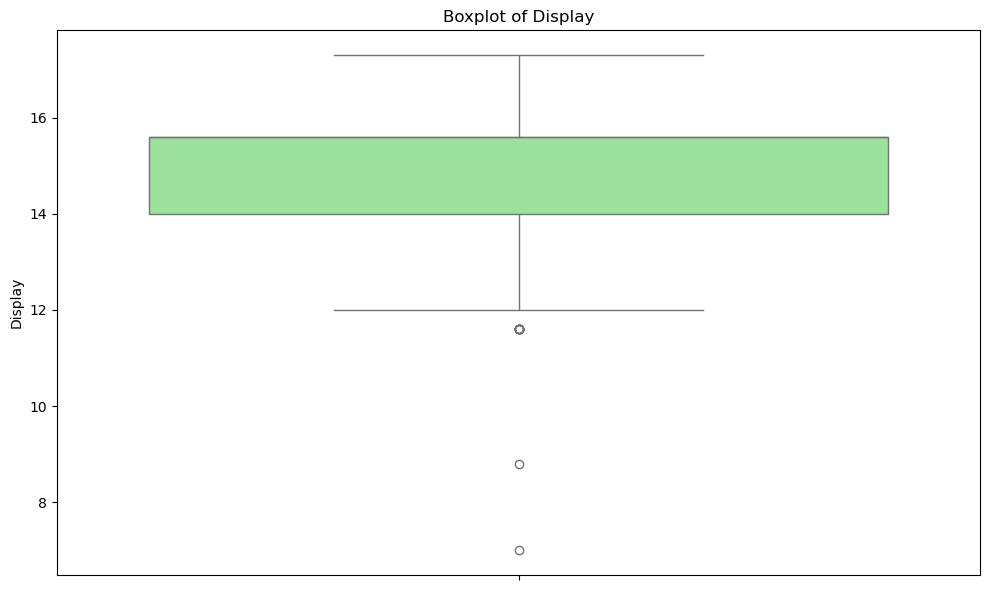

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(y=df['Display'], color='lightgreen')
plt.title("Boxplot of Display")
plt.tight_layout()
plt.show()

##### Boxplot interpretation
* Some small screen sizes (7, 8, 11) appear as outliers
* Most laptops are 14–15.6 inches

#### Best method: Median
* Since Distribution is skewed, Outliers exist.

In [35]:
df['Display'].fillna(df['Display'].median(), inplace=True)

In [36]:
df['Display'].isnull().sum()

np.int64(0)

### Original_Price (25 missing → 4.38%)

In [37]:
df['Original_Price'].isnull().sum()

np.int64(25)

In [38]:
df['Original_Price'].skew()

np.float64(1.8271764805126416)

##### Skewness
* Strong right skew.

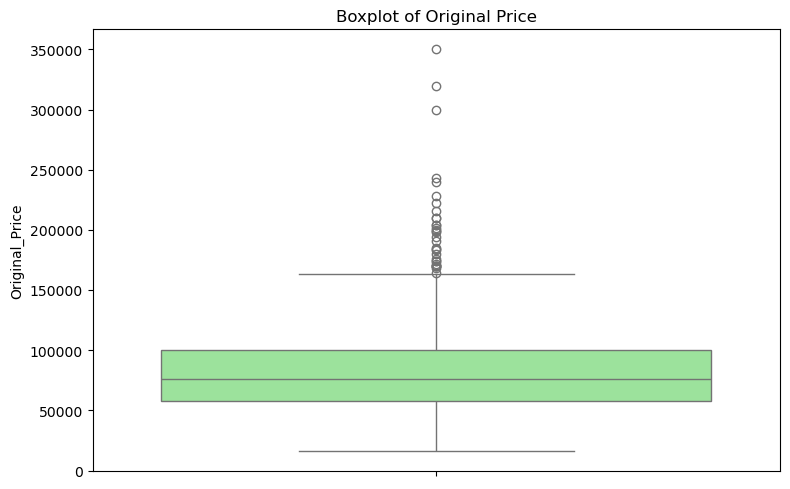

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Original_Price'], color='lightgreen')
plt.title("Boxplot of Original Price")
plt.tight_layout()
plt.show()

##### Boxplot interpretation
* Many high price laptops (200k–350k) appear as outliers
* Majority range is 50k–100k

#### Best method
* Missing values in Original_Price were filled using Selling_Price because discount-related fields were also missing.
* Using statistical measures like mean or median could violate the business rule that Original Price must be greater than or equal to Selling Price.

In [40]:
df['Original_Price'] = df['Original_Price'].fillna(df['Selling_Price'])

In [41]:
df['Original_Price'].isnull().sum()

np.int64(0)

### Discount_Amount (25 missing → 4.38%)

In [42]:
df['Discount_Amount'].isnull().sum()

np.int64(25)

#### Best Method
* Discount amount follows a formula:
    * Discount Amount = Original Price − Selling Price
* So instead of statistical imputation, we should use business logic.

In [43]:
df['Discount_Amount'].fillna( df['Original_Price'] - df['Selling_Price'], inplace=True)

In [44]:
df['Discount_Amount'].isnull().sum()

np.int64(0)

### SSD (27 missing → 4.73%)

In [45]:
df['SSD_GB'].isnull().sum()

np.int64(27)

In [46]:
df['SSD_GB'].skew()

np.float64(1.7013901866253809)

##### Skewness
* Right skewed distribution.

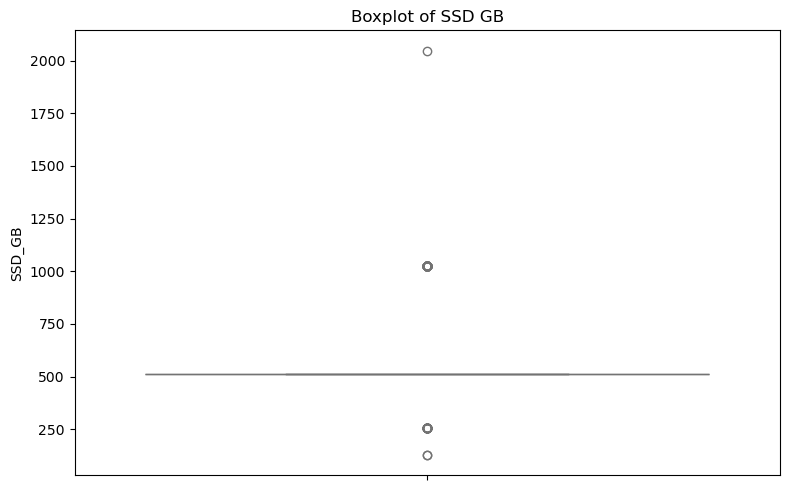

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['SSD_GB'], color='lightgreen')
plt.title("Boxplot of SSD GB")
plt.tight_layout()
plt.show()

##### Boxplot interpretation
* Most laptops have 512GB
* Some have 1TB or 2TB (outliers)
* Laptop SSD sizes are usually:
    * 256GB, 512GB, 1TB, 2TB
#### Best method: Median
* SSD capacity depends on laptop configuration such as RAM, processor and brand.
* Therefore missing values were imputed using the median SSD capacity within similar configuration groups to preserve realistic hardware combinations.

In [48]:
df['SSD_GB'] = df.groupby(['Brand','Processor','RAM'])['SSD_GB'].transform(lambda x: x.fillna(x.median()))

In [49]:
df['SSD_GB'].isnull().sum()

np.int64(16)

In [50]:
#  Still missing, fill with overall median
df['SSD_GB'].fillna(df['SSD_GB'].median(), inplace=True)

df['SSD_GB'].isnull().sum()

np.int64(0)

### Discount_on_OriginalPrice (33 missing → 5.78%)

In [51]:
df['Discount_on_OriginalPrice'].isnull().sum()

np.int64(33)

#### Best method
* Discount percentage was calculated using the relationship between Discount Amount and Original Price to maintain logical consistency in the dataset.

In [52]:
df['Discount_on_OriginalPrice'].fillna(
    ((df['Original_Price'] - df['Selling_Price']) / df['Original_Price']) * 100,
    inplace=True )

df['Discount_on_OriginalPrice'].isnull().sum()

np.int64(0)

#### Rating (77 missing → 13.49%)

In [53]:
df['Rating'].skew()

np.float64(-0.8990932817761413)

##### Skewness
* Left skewed distribution.

In [54]:
df['Rating'].isnull().sum()

np.int64(77)

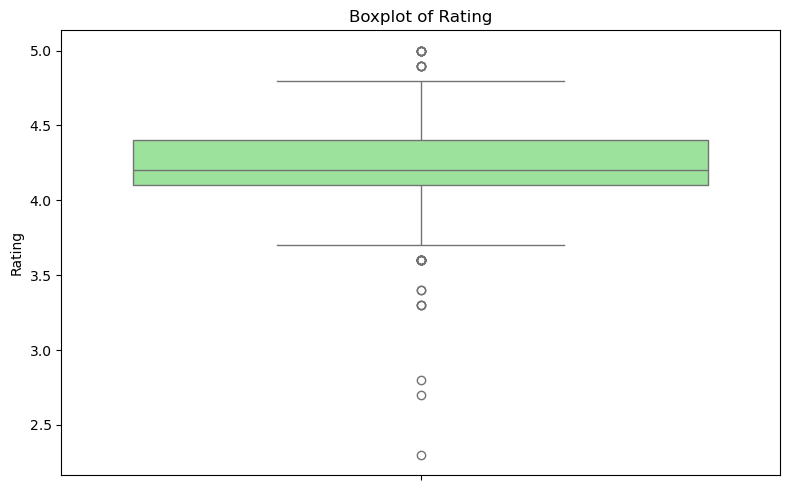

In [55]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Rating'], color='lightgreen')
plt.title("Boxplot of Rating")
plt.tight_layout()
plt.show()

##### Interpretation
* Most ratings are high (4–5).
* Few low ratings appear below 3.5 as outliers
* Ratings are missing because: Laptop may not have many reviews yet.
#### Best method: Median
* Ratings are skewed. Median gives stable central value

In [56]:
df['Rating'] = df.groupby(['Brand','Processor','RAM','SSD_GB'])['Rating'].transform(lambda x: x.fillna(x.median()))

In [57]:
df['Rating'].isnull().sum()

np.int64(34)

In [58]:
df['Rating'] = df.groupby('Brand')['Rating'].transform(lambda x: x.fillna(x.median()))

In [59]:
df['Rating'].isnull().sum()

np.int64(0)

In [60]:
df

,Brand,Processor,OS,RAM,RAM_Type,Display,Selling_Price,Original_Price,Discount_on_OriginalPrice,Rating,SSD_GB,Discount_Amount
0,DELL,Intel Core Ultra 5,Windows 11 Home,16,LPDDR5X,14.0,77990,98040.0,20.0,4.3,512.0,20050.0
1,DELL,Snapdragon X,Windows 11 Home,16,LPDDR5X,14.0,60990,87704.0,30.0,4.2,512.0,26714.0
2,ASUS,Intel Core i3,Windows 11 Home,8,DDR4,14.0,40990,50990.0,19.0,4.3,512.0,10000.0
3,Lenovo,MediaTek Kompanio 520,Chrome,4,LPDDR4X,11.6,14999,16298.0,7.0,4.0,512.0,1299.0
4,Acer,Intel Core i3,64 bit Windows 11 Home,8,DDR4,15.6,38938,42990.0,9.0,4.0,512.0,4052.0
...,...,...,...,...,...,...,...,...,...,...,...,...
566,HP,Intel Core i5,64 bit Windows 11,8,DDR4,15.6,53690,64400.0,16.0,3.6,512.0,10710.0
567,ASUS,AMD Ryzen 7 Octa Core,64 bit Windows 11,16,DDR4,15.6,87600,98990.0,11.0,4.1,512.0,11390.0
568,HP,Intel Core i5,64 bit Windows 11,16,DDR4,15.6,54143,62990.0,14.0,4.3,512.0,8847.0
569,DELL,Intel Core i5,Linux/Ubuntu,16,DDR4,14.0,59989,79990.0,25.0,3.7,512.0,20001.0


In [61]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RAM,571.0,13.789842,5.885275,4.0,8.0,16.0,16.0,36.0
Display,571.0,14.951313,1.072026,7.0,14.0,15.6,15.6,17.3
Selling_Price,571.0,67713.352014,39322.608497,14240.0,42445.0,57339.0,77994.5,330990.0
Original_Price,571.0,86391.884413,43782.740854,16298.0,57729.5,75990.0,99994.5,349900.0
Discount_on_OriginalPrice,571.0,21.739001,12.187367,0.0,13.0,21.0,30.0,55.0
Rating,571.0,4.218914,0.299050,2.3,4.1,4.2,4.3,5.0
SSD_GB,571.0,573.870403,214.492867,128.0,512.0,512.0,512.0,2048.0
Discount_Amount,571.0,18678.532399,13509.837498,0.0,9611.0,16600.0,25004.5,103000.0


In [62]:
df.describe(include = object).T

,count,unique,top,freq
Brand,571,19,ASUS,131
Processor,571,48,Intel Core i5,139
OS,571,13,Windows 11,226
RAM_Type,571,9,DDR4,259


### Interpretation

#### Brand
* Count = 571 → All rows have brand information.
* Unique = 19 → Dataset contains 19 different laptop brands.
* Most frequent (top) = ASUS → 131 laptops (~23%) are ASUS.
* **Conclusion:** ASUS is the dominant brand in this dataset, followed by other popular brands (like Dell, HP, Lenovo). Brand is important for market segmentation and consumer preference analysis.

#### Processor
* Count = 571 → All laptops have processor info.
* Unique = 48 → Wide variety of processors across models.
* Most frequent = Intel Core i5 → 139 laptops (~24%) have i5 processors.
* **Conclusion:** Intel Core i5 dominates, indicating mid-range laptops are most common. The large number of unique processors reflects diversity in laptop performance (entry-level to high-end). Processor is a key feature affecting price and performance classification.

#### OS (Operating System)
* Count = 571 → No missing OS data.
* Unique = 13 → Multiple operating systems present.
* Most frequent = Windows 11 → 226 laptops (~40%) run Windows 11.
* **Conclusion:** Windows dominates the laptop market, with macOS and Linux being minority segments. OS helps identify compatibility for software and consumer preference.

#### RAM (GB)
* Average = 13.8 GB → Most laptops have 8–16 GB, reflecting modern mid-range to high-end specs.
* Standard deviation = 5.88 → Wide variation, from entry-level to very high-end laptops.
* Min = 4 GB, Max = 36 GB → Dataset covers basic to workstation/gaming laptops.
* Median = 16 GB → Most common RAM size in current laptops.
* 25% percentile = 8 GB → Entry-level to mid-range laptops.
* 36 GB RAM laptops → Very high-end or specialized laptops.
* **Conclusion:** RAM is a strong differentiator between budget, mid-range, and premium laptops.

#### RAM_Type
* Count = 571 → All laptops have RAM type specified.
* Unique = 9 → Different RAM types available.
* Most frequent = DDR4 → 259 laptops (~45%) use DDR4 RAM.
* **Conclusion:** DDR4 is the standard RAM type, indicating most laptops are modern but not the latest (DDR5 exists in some high-end laptops). RAM type is less critical for market segmentation but important for performance categorization.

#### Display (inches)
* Average = 14.95” → Most laptops are 15-inch class, standard size for modern laptops.
* Min = 7”, Max = 17.3” → Some mini laptops or large workstations.
* Median = 15.6”, 25% = 14”, 75% = 15.6” → Standard screen sizes dominate.
* **Conclusion:** Display size is mostly fixed; not a strong differentiator for market analysis.

#### Selling Price
* Average = ₹67,713 → Most laptops are mid to high-range, with many premium models.
* High variation → Prices vary a lot (some budget laptops, some very costly).
* Standard deviation = 39,323 → Prices vary a lot across budget, mid-range, and premium laptops.
* Min = ₹14,240, Max = ₹330,990 → Dataset includes budget laptops to extremely high-end gaming/workstation models.
* 25% percentile = ₹42,445 → Lower mid-range laptops.
* Median = ₹57,339 → Typical laptop in the dataset is mid-range to high-range.
* 75% percentile = ₹77,994 → Upper mid-range to premium.
* Few laptops above ₹3,00,000 → Very high-end or luxury models.
* **Conclusion:** Price distribution is wide, reflecting different market segments.

#### Original Price (MRP)
* Average = ₹86,392 → On average, laptops have a higher original price than selling price, indicating discounts are common.
* Min = ₹16,298, Max = ₹349,900 → Includes budget to extremely high-end models.
* Median = ₹75,990 → Most laptops are priced mid-range to premium.
* 75% laptops < ₹99,994 → Premium laptops exist but are fewer.
* Difference between original price and selling price shows discounts applied.

#### Discount_on_OriginalPrice (%)
* Average discount = 21.7% → Moderate discount offered on laptops.
* Min = 0%, Max = 55% → Some laptops are full price, some heavily discounted.
* Median = 21%, 25% = 13%, 75% = 30% → Most laptops have 10–30% discount, a common market trend.
* **Conclusion:** Discounts are meaningful and vary with product segment.

#### Rating
* Average = 4.22 → Laptops are generally well-rated.
* Standard deviation = 0.29 → Some variation exists, more than phones, but still most laptops are rated positively.
* Min = 2.3, Max = 5 → Few poorly rated products; most above 4.
* Median = 4.2, 25% = 4.1, 75% = 4.3 → Most laptops have 4+ rating, indicating good customer satisfaction.
* **Conclusion:** Ratings provide some distinction, but most laptops are highly rated.

#### SSD (Storage in GB)
* Average = 573 GB → Storage is generally high, many laptops have 512 GB SSD.
* Min = 128 GB, Max = 2,048 GB → Covers entry-level to high-end workstations/gaming laptops.
* Median = 512 GB, 25% percentile = 512 GB, 75% percentile = 512 GB → Most laptops have 512 GB SSD.
* **Conclusion:** SSD is mostly standard, except for very high-end laptops; good for segmenting premium models.

#### Discount_Amount (₹)
* Average discount = ₹18,679 → On average, customers save a significant amount per laptop.
* Min = ₹0, Max = ₹103,000 → Huge discounts exist on premium models.
* 25% percentile = ₹9,611, Median = ₹16,600, 75% percentile = ₹25,005 → Most discounts are moderate to high.
* **Conclusion:** Discount amount is aligned with selling price and clearly highlights savings.

#### Final Summary
* **Prices :** Selling price and original price vary widely; dataset contains budget, mid-range, premium, and ultra-premium laptops.
* **Discounts :** Both percentage and absolute discounts vary, reflecting real market strategies.
* **Ratings :** Most laptops are positively rated (4+), but a few poorly rated laptops exist.
* **RAM & SSD :** Clear distinction between entry-level, mid-range, and premium laptops.
* **Display :** Most laptops are standard 15-inch; little differentiation.
* **Brand :** ASUS dominates (~23% of laptops), followed by Dell, HP, Lenovo; brand is important for market segmentation.
* **Processor :** Intel Core i5 is most common (~24%); processor indicates mid-range performance for most laptops.
* **OS :** Windows 11 dominates (~40%); OS is important for consumer preference and software compatibility.
* **RAM Type :** DDR4 is standard (~45%); indicates most laptops are modern but not latest generation.

**Final Note :** Price, RAM, SSD, and processor are key factors for market segmentation, while brand, OS, ratings, and display provide supporting insights. Discounts reflect pricing strategies and vary with product segment.

## Univariate Analysis

### Numeric Columns

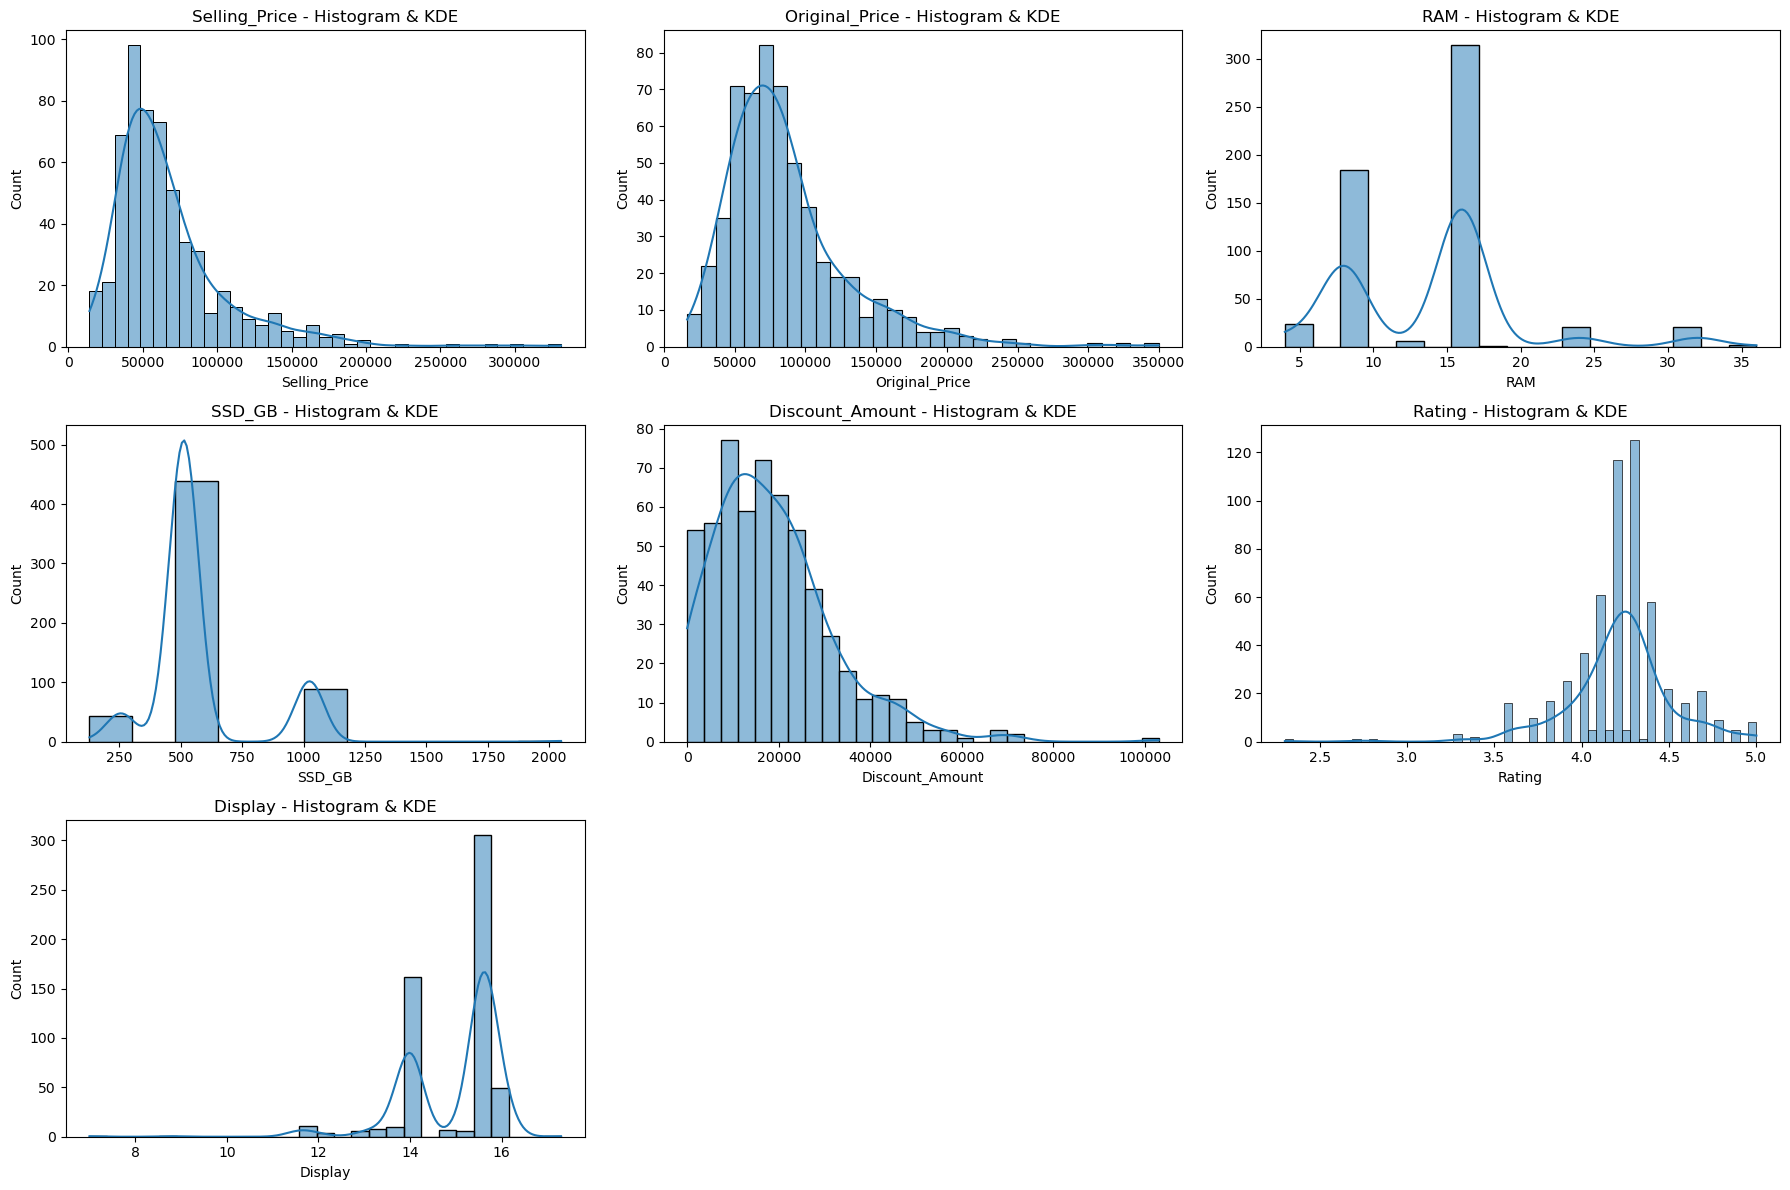

In [63]:
# Histogram + KDE of Numerical Variables
num_cols = ["Selling_Price", "Original_Price", "RAM", "SSD_GB", "Discount_Amount", "Rating", "Display"]

plt.figure(figsize=(18,12))
for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde=True, palette='tab10')
    plt.title(f"{col} - Histogram & KDE")
plt.tight_layout()
plt.show()

### Insight:
* **Selling_Price:** Most laptops are priced between ₹40,000–₹80,000 with a right-skewed distribution indicating a few high-priced premium models.
* **Original_Price:** The original price distribution shows most laptops fall in the mid-range segment with a few expensive outliers.
* **RAM:** The market is dominated by 8GB and 16GB RAM laptops, indicating the standard configuration.
* **SSD_GB:** 512GB SSD is the most common storage option, making it the industry standard.
* **Discount_Amount:** Most laptops receive moderate discounts between ₹5,000 and ₹20,000.
* **Rating:** Laptop ratings are generally high, mostly ranging between 4.0 and 4.5. Most laptops listed on Flipkart receive positive customer feedback.
* **Display:** Most laptops feature 14–15.6 inch screens, showing the preferred size for portability and usability.

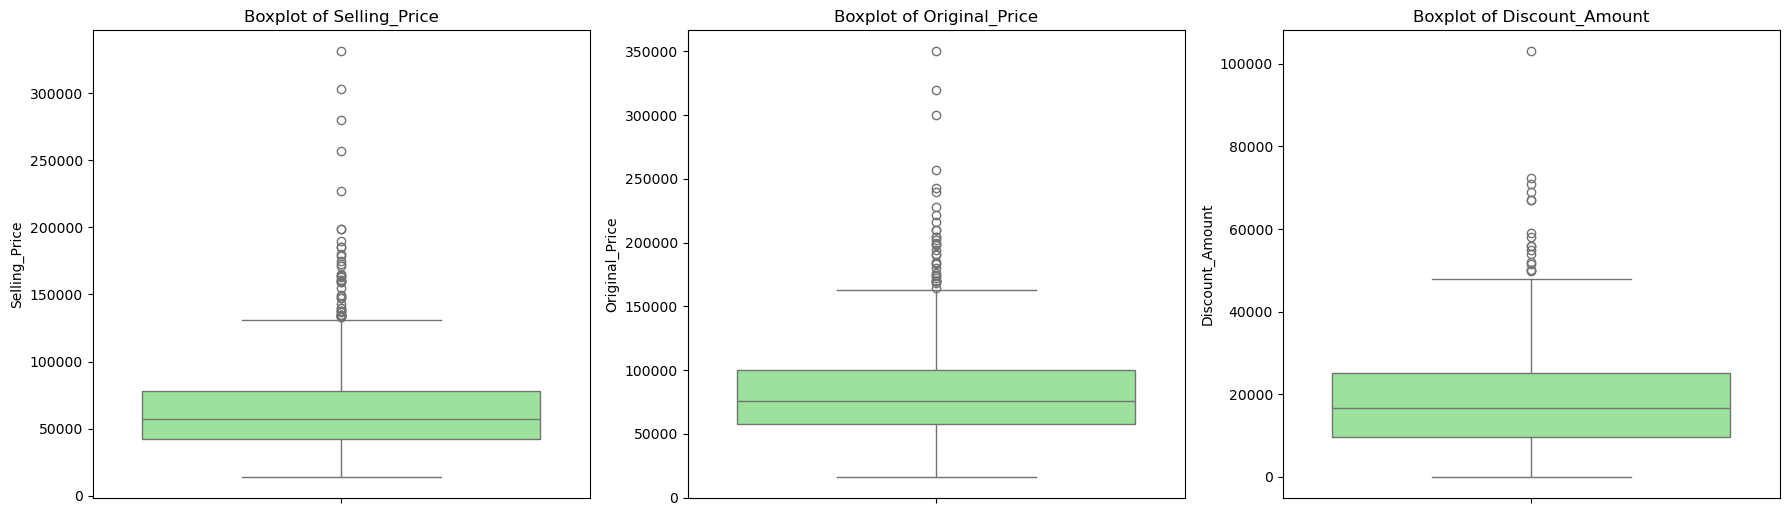

In [64]:
# Boxplots of Prices

num_cols = ["Selling_Price", "Original_Price", "Discount_Amount"]

plt.figure(figsize=(18,15))
for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

### Insight
* Large variation in laptop prices.
* Premium laptops create outliers above ₹150k.

#### Market Insight
* Laptop market contains budget, mid-range, and premium segments.

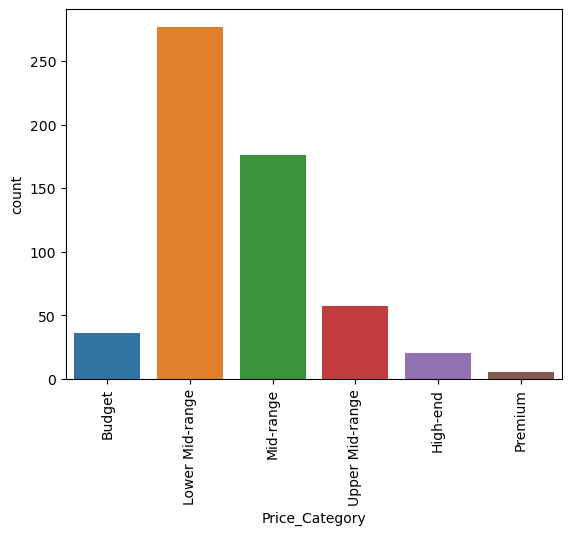

In [65]:
# Price_Category Distribution based on Selling_Price
df['Price_Category'] = pd.cut(
    df['Selling_Price'],
    bins=[0, 30000, 60000, 100000, 150000, 200000, 350000],
    labels=['Budget', 'Lower Mid-range', 'Mid-range', 'Upper Mid-range', 'High-end', 'Premium']
)

sns.countplot(x='Price_Category', data=df, palette='tab10')
plt.xticks(rotation=90)
plt.show()

### Insight
Most laptops fall into:
* Lower Mid-range
* Mid-range

Few laptops are:
* Premium
* High-end
#### Market Insight
* Mid-range laptops dominate the Flipkart market.

### Categorical Columns

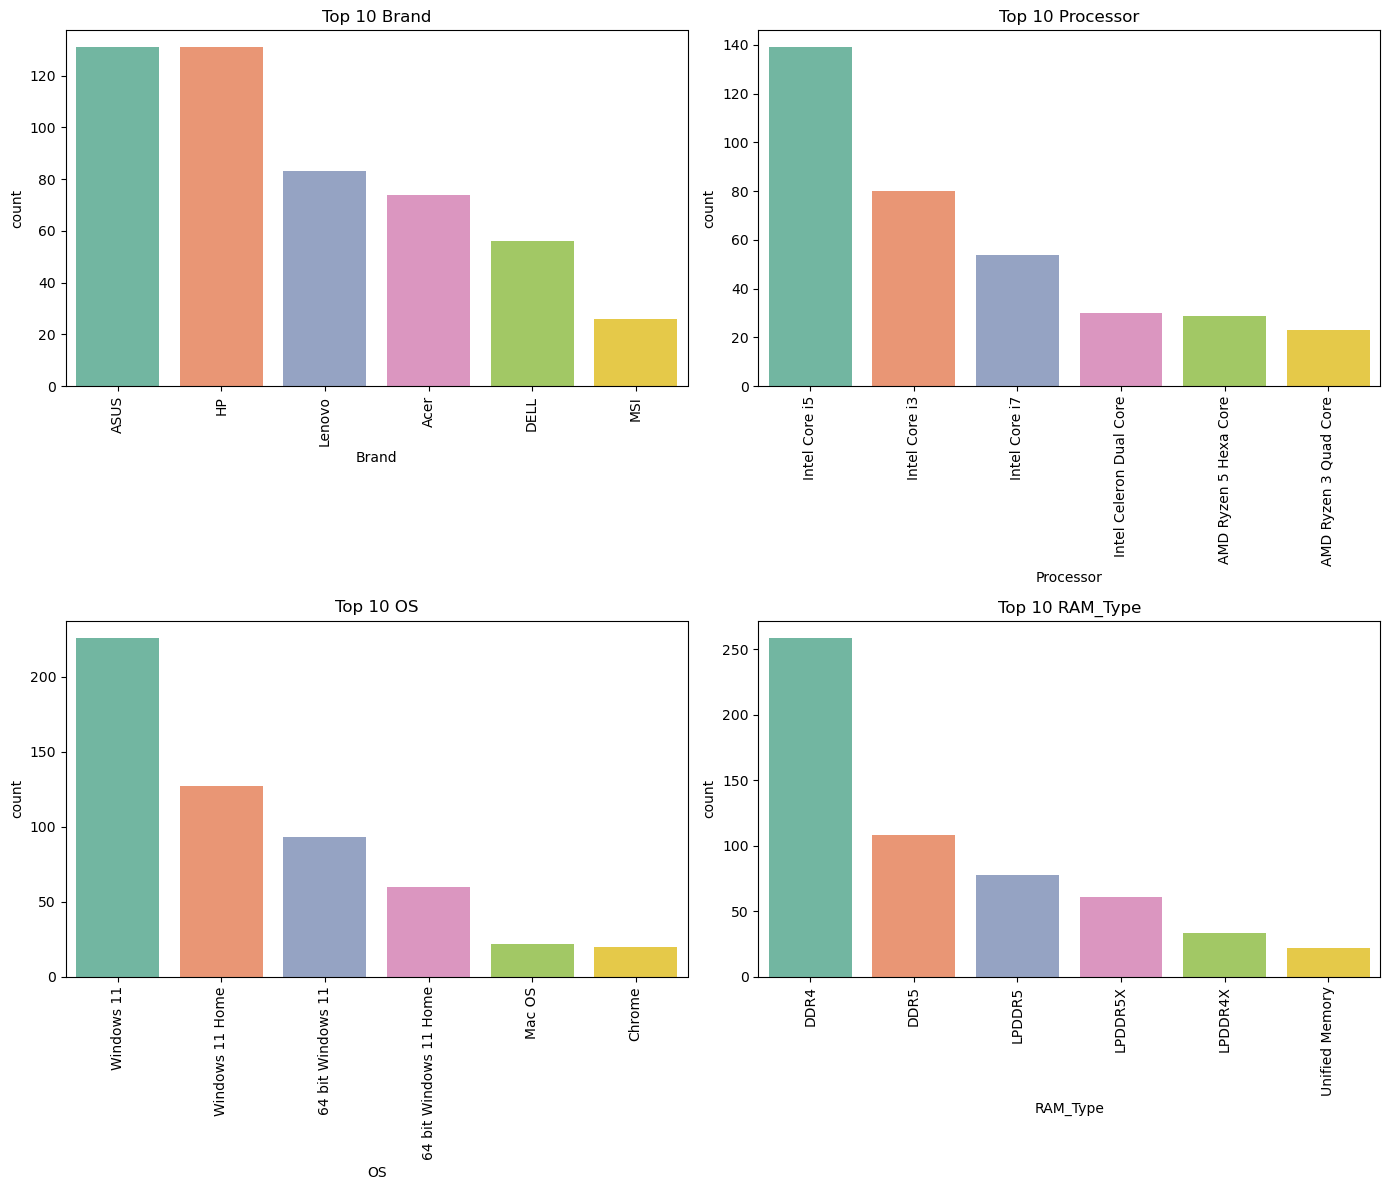

In [66]:
# Top Categories (Brand, Processor, OS, RAM Type)
cat_cols = ["Brand", "Processor", "OS", "RAM_Type"]

plt.figure(figsize=(14,12))
for i, col in enumerate(cat_cols):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df[col], order=df[col].value_counts().nlargest(6).index, palette='Set2')
    plt.xticks(rotation=90)
    plt.title(f"Top 10 {col}")
plt.tight_layout()
plt.show()

#### Insight
* **Brand Chart:** HP, Lenovo, ASUS, Dell, and Acer have the highest number of laptops, showing they dominate the market.
* **Processor Chart:** Intel i5 is the most common processor, followed by Intel i7 and Intel i3.
* **OS Chart:** Most laptops come with Windows 11 as the operating system.
* **RAM Type Chart:** DDR4 RAM is used in most laptops, while DDR5 is gradually increasing in newer models

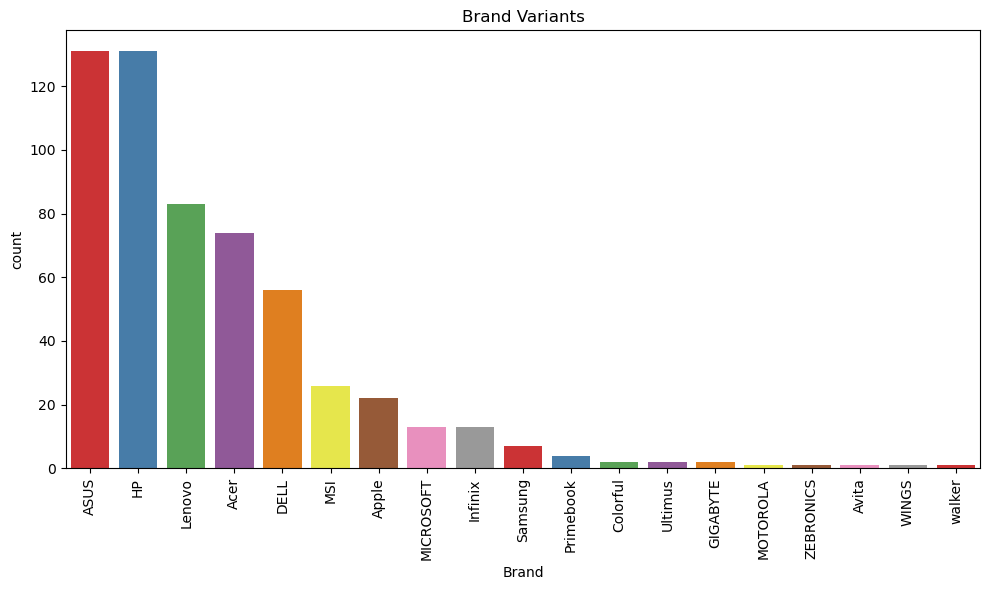

In [67]:
# Brand Variants(Brand Distribution)

plt.figure(figsize=(10,6))
sns.countplot(x=df["Brand"], order=df["Brand"].value_counts().index, palette='Set1')
plt.title("Brand Variants")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Insight
* HP, Lenovo, ASUS, Dell, and Acer are the most frequently listed laptop brands.

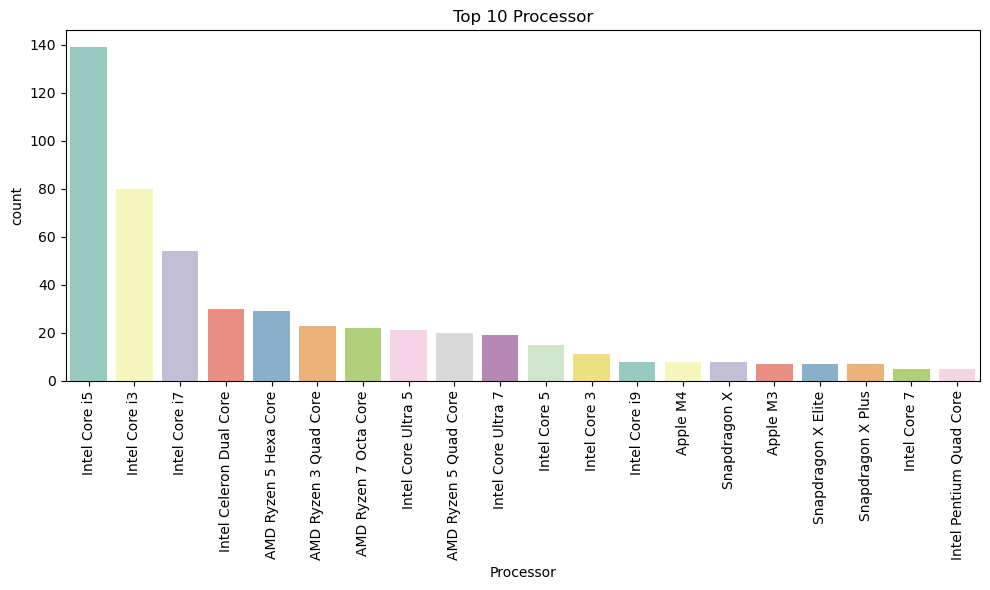

In [68]:
plt.figure(figsize=(10,6))
sns.countplot(x=df["Processor"], order=df["Processor"].value_counts().nlargest(20).index, palette='Set3')
plt.title("Top 10 Processor")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Insight
Intel i5 processors are the most common, followed by i7 and i3.

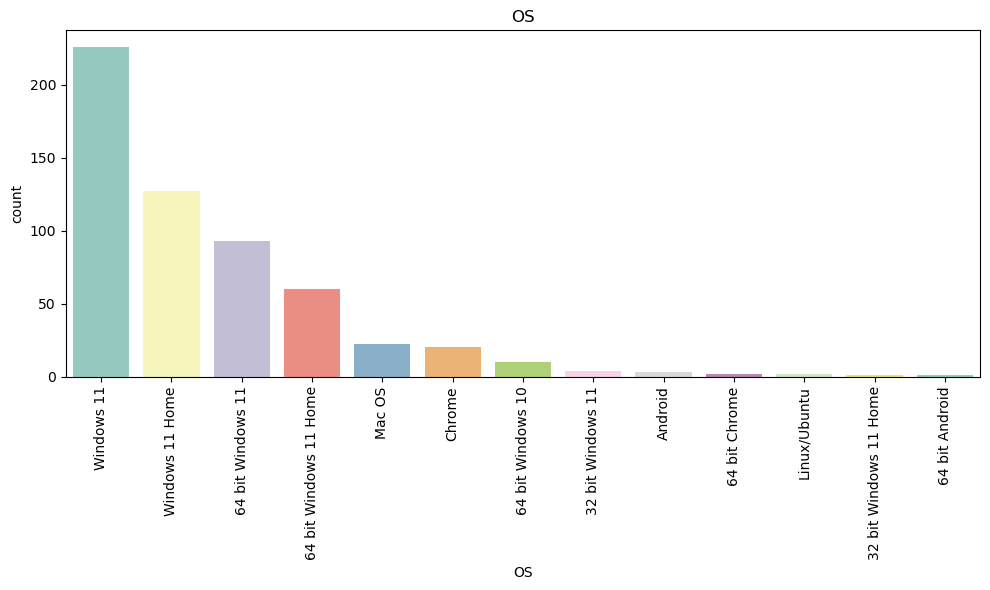

In [69]:
plt.figure(figsize=(10,6))
sns.countplot(x=df["OS"], order=df["OS"].value_counts().index, palette='Set3')
plt.title("OS")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Insight
Operating systems:
* Windows 11 → majority
* Windows 10 → few
* macOS → Apple laptops
#### Market Insight
* Most laptops run on Windows 11, making it the dominant operating system.

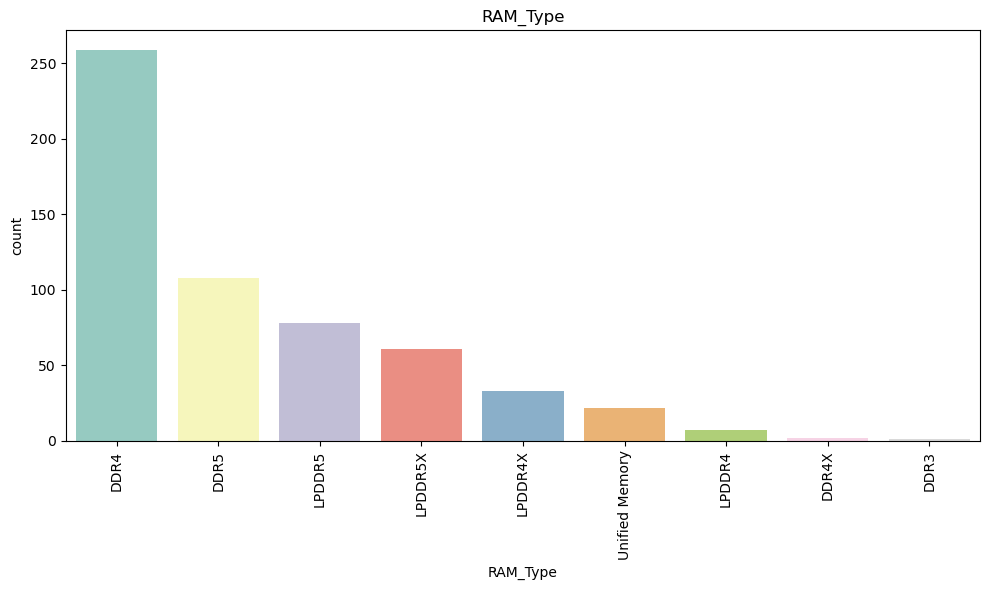

In [70]:
plt.figure(figsize=(10,6))
sns.countplot(x=df["RAM_Type"], order=df["RAM_Type"].value_counts().index, palette='Set3')
plt.title("RAM_Type")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Insight
RAM types:
* DDR4 → most common
* DDR5 → increasing in newer laptops
#### Market Insight
* DDR4 RAM is the most widely used memory type, while DDR5 is gradually increasing in newer models.

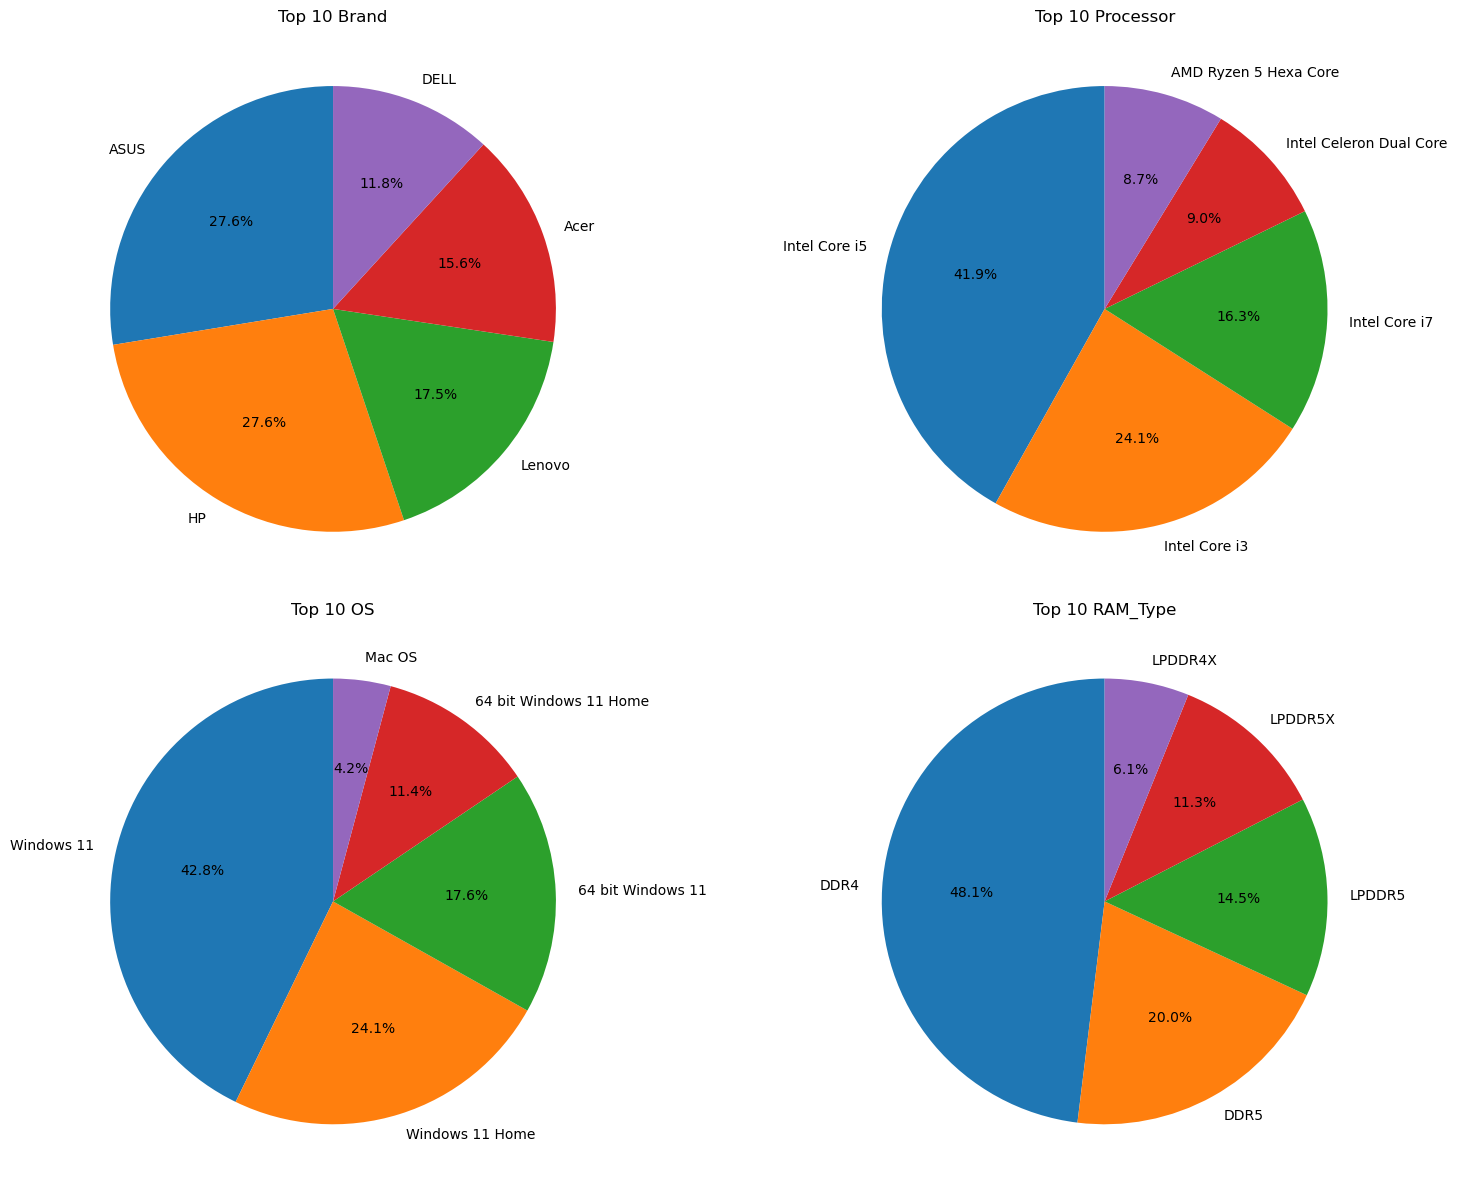

In [71]:
# Pie Charts of Categories
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top10 = df[col].value_counts().nlargest()
    axes[i].pie(top10.values, labels=top10.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f"Top 10 {col}")
plt.tight_layout()
plt.show()

### Insights
Shows proportion of:
* Brand
* Processor
* OS
* RAM type
### Market Insight
* Few brands dominate listings.
* Intel processors have majority share.
* Windows OS dominates.

## Bivariate Anlysis

### 1. Numerical vs Numerical

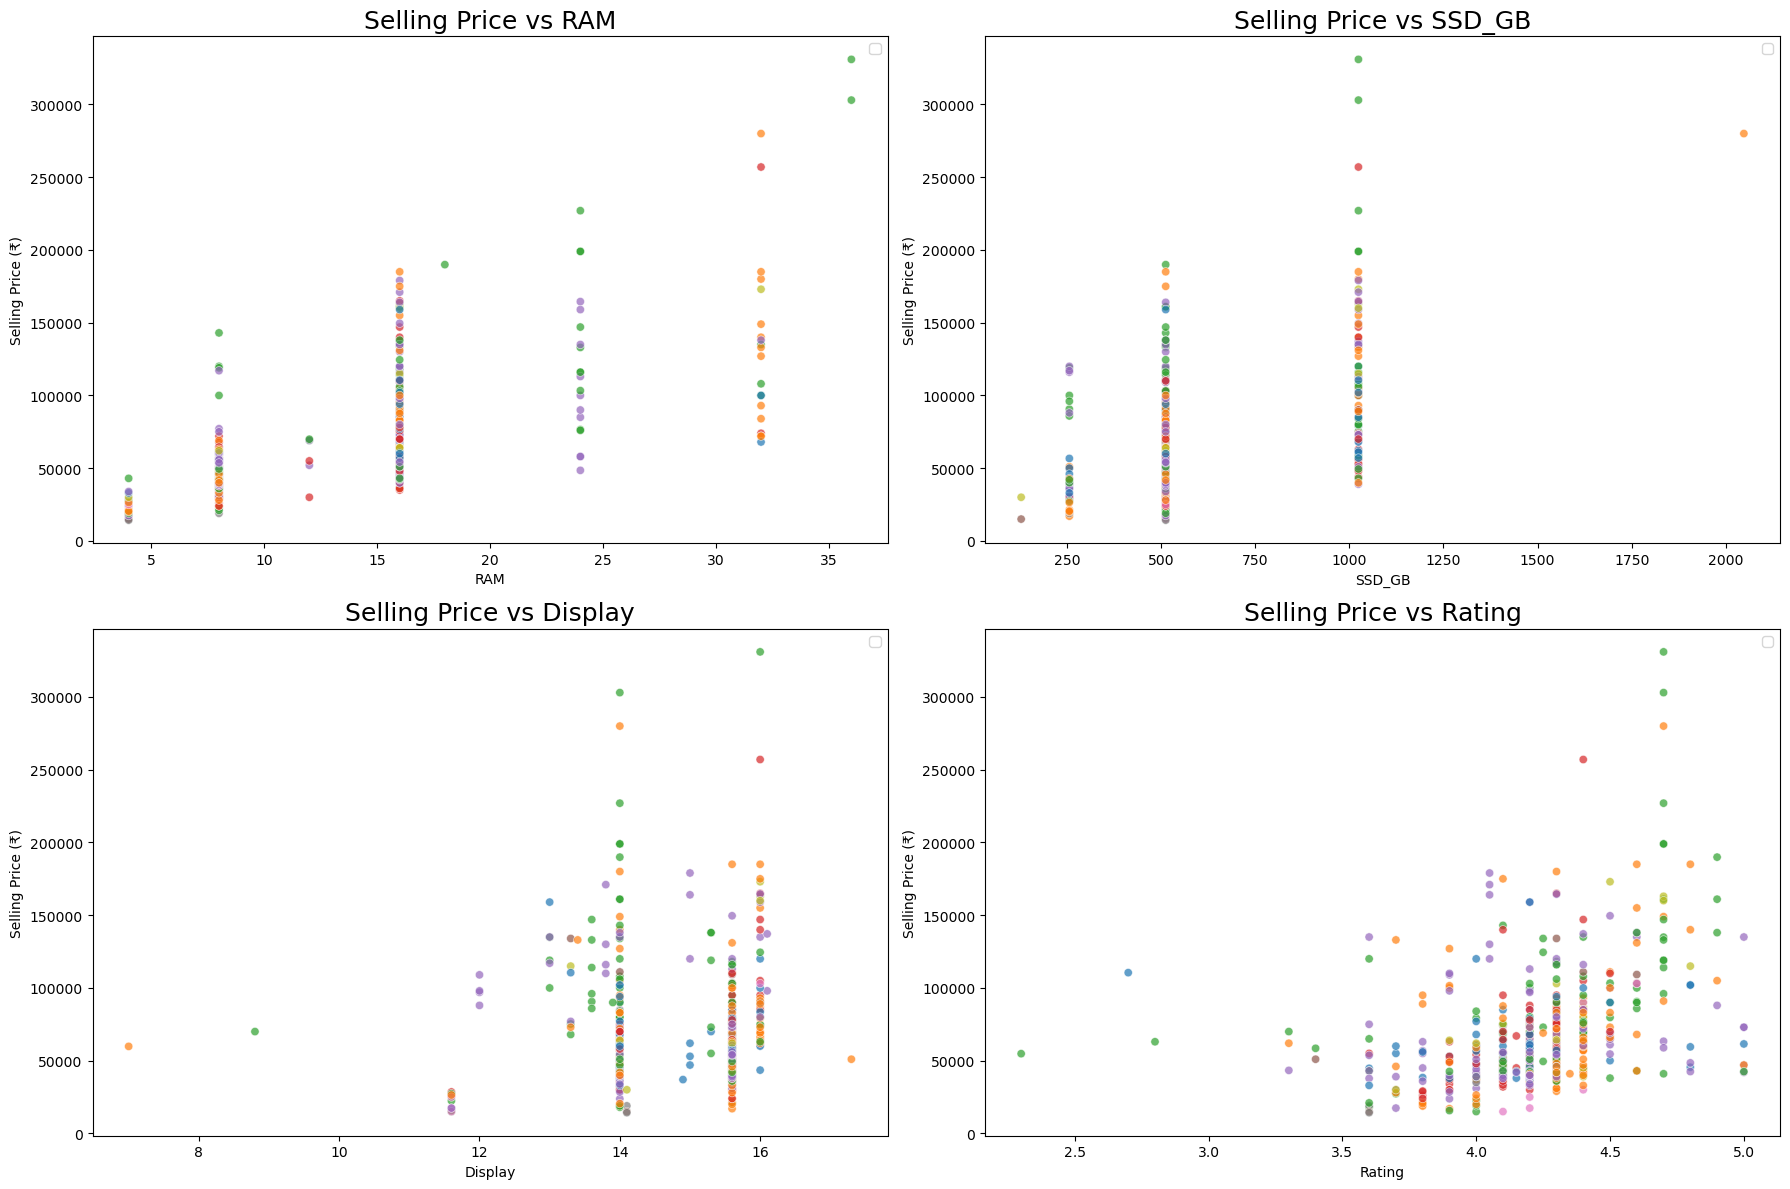

In [72]:
# Scatter Plot (Selling Price vs Features)
plt.figure(figsize=(18,12))
for i, col in enumerate(["RAM", "SSD_GB", "Display", "Rating"]):
    plt.subplot(2,2,i+1)
    sns.scatterplot(y="Selling_Price", x=col, data=df, hue="Brand", alpha=0.7, palette='tab10')
    plt.title(f"Selling Price vs {col}", fontsize=18)
    plt.xlabel(col)
    plt.ylabel("Selling Price (₹)")
    plt.legend([],[])
plt.tight_layout()
plt.show()

#### Insight
* **RAM vs Price:** Strong positive relationship. Laptop price generally increases as RAM size increases.
* **SSD vs Price:** Laptops with larger SSD storage tend to have higher prices.
* **Display vs Price:** Laptops with larger display sizes tend to have slightly higher prices.
* **Rating vs Price:** Weak relationship. Laptop ratings show little direct relationship with price. Expensive laptops are not always higher rated.

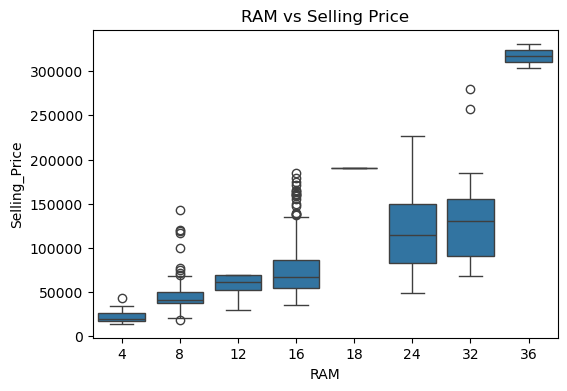

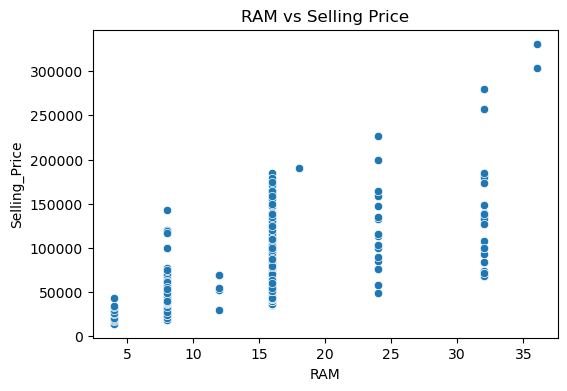

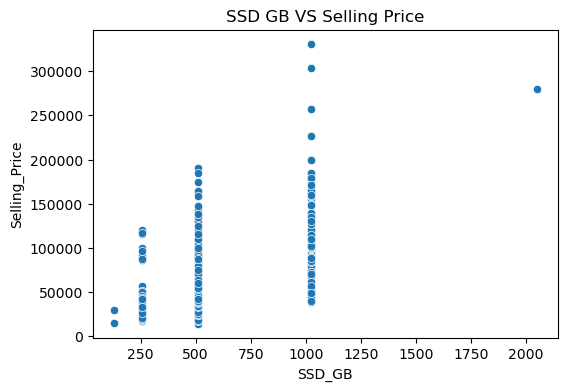

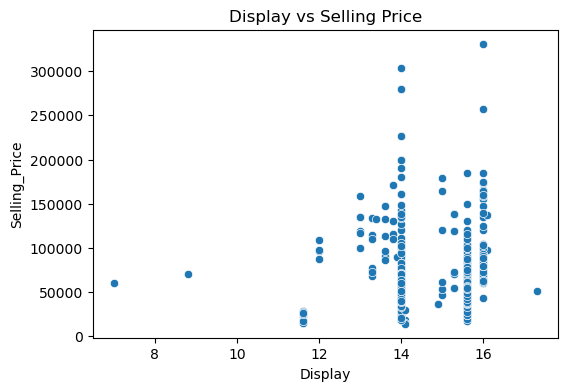

In [103]:
# RAM vs Selling Price
plt.figure(figsize=(6,4))
sns.boxplot(x='RAM', y='Selling_Price', data=df)
plt.title('RAM vs Selling Price')
plt.show()

# RAM vs Selling Price
plt.figure(figsize=(6,4))
sns.scatterplot(x="RAM", y="Selling_Price", data=df, palette="Set2")
plt.title('RAM vs Selling Price')
plt.show()

# SSD vs Selling Price
plt.figure(figsize=(6,4))
sns.scatterplot(x="SSD_GB", y="Selling_Price", data=df, palette="Set2")
plt.title("SSD GB VS Selling Price")
plt.show()

# RAM vs Selling Price
plt.figure(figsize=(6,4))
sns.scatterplot(x="Display", y="Selling_Price", data=df, palette="Set2")
plt.title('Display vs Selling Price')
plt.show()

### Insight
#### RAM vs Selling Price
* Price increases as RAM increases.
#### SSD vs Selling Price
* 256GB → budget laptops
* 512GB → mid range
* 1TB → premium laptops
* Higher SSD storage options are associated with more expensive laptops.

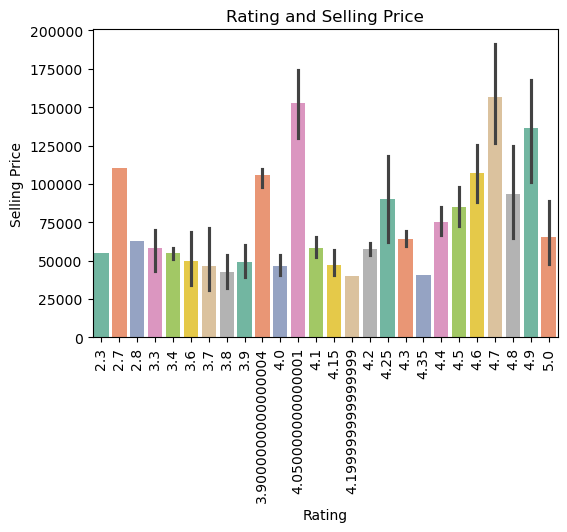

In [74]:
# Rating vs Selling Price
plt.figure(figsize=(6,4))
sns.barplot(x="Rating", y="Selling_Price", data=df, palette="Set2")
plt.title("Rating and Selling Price")
plt.xlabel("Rating")
plt.xticks(rotation=90)
plt.ylabel("Selling Price")
plt.show()

### Insight
* Higher ratings appear in mid-range laptops, not necessarily the most expensive ones.

### 2. Categorical vs Categorical

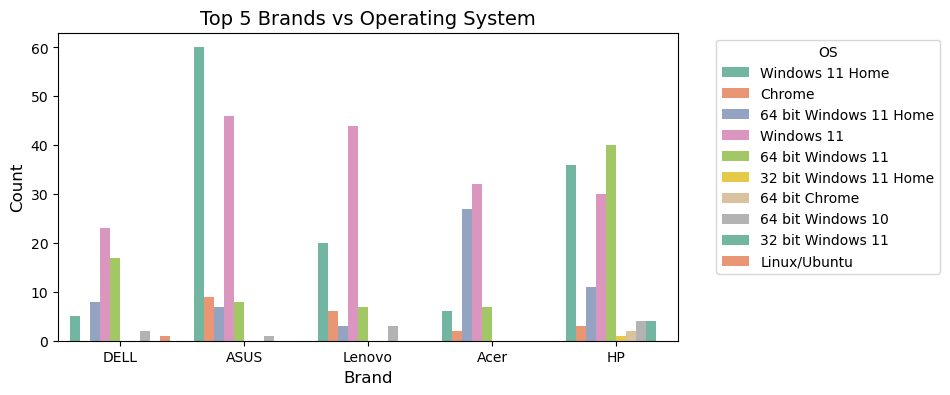

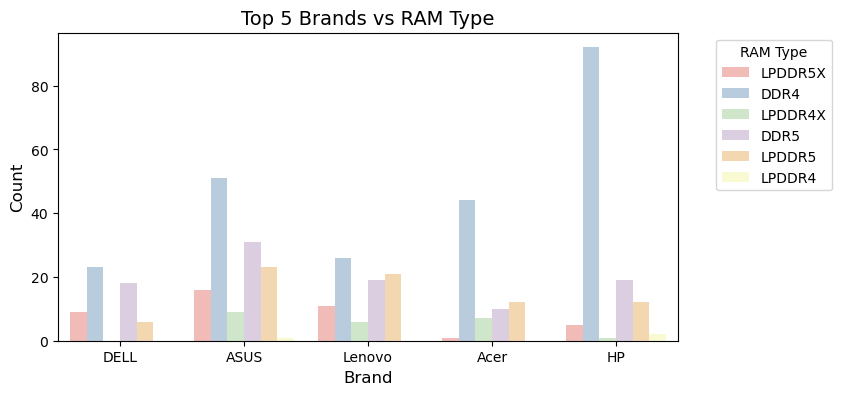

In [75]:
top_5_brands = df['Brand'].value_counts().head(5).index
df_top5 = df[df['Brand'].isin(top_5_brands)]

# Plot: Top 5 Brands vs OS
plt.figure(figsize=(8,4))
sns.countplot(x="Brand", hue="OS", data=df_top5, palette='Set2')
plt.title("Top 5 Brands vs Operating System", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title='OS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Plot: Top 5 Brands vs RAM_Type
plt.figure(figsize=(8,4))
sns.countplot(x="Brand", hue="RAM_Type", data=df_top5, palette='Pastel1')
plt.title("Top 5 Brands vs RAM Type", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title='RAM Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Insight
* Most brands ship Windows laptops.
* Apple uses macOS only.

### 3. Categorical vs Numeric

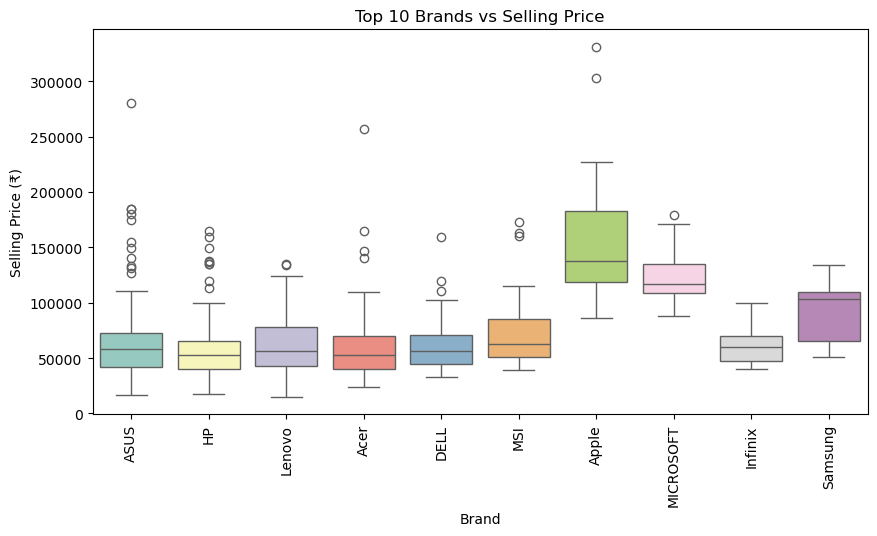

In [76]:
# Boxplot: Top 10 Brands vs Operating System
plt.figure(figsize=(10,5))
sns.boxplot(x="Brand", y="Selling_Price", data=df, palette='Set3', order=df['Brand'].value_counts().nlargest(10).index)
plt.title("Top 10 Brands vs Selling Price")
plt.ylabel("Selling Price (₹)")
plt.xlabel("Brand")
plt.xticks(rotation=90)
plt.show()

### Insight
Premium pricing brands:
* Apple
* ASUS (gaming)
* Dell (premium series)
  
Budget brands:
* Acer
* HP
* Lenovo

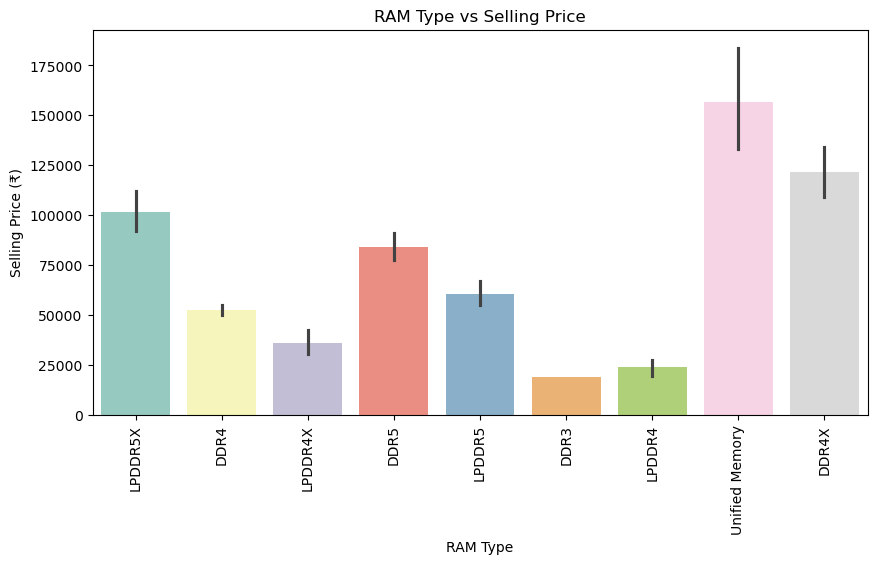

In [77]:
# RAM Type vs Selling Price
plt.figure(figsize=(10,5))
sns.barplot(x="RAM_Type", y="Selling_Price", data=df, palette='Set3')
plt.title("RAM Type vs Selling Price")
plt.ylabel("Selling Price (₹)")
plt.xlabel("RAM Type")
plt.xticks(rotation=90)
plt.show()

### Insight
* Laptops with DDR5 RAM are more expensive.
* Laptops with DDR5 RAM are generally priced higher than DDR4 models.

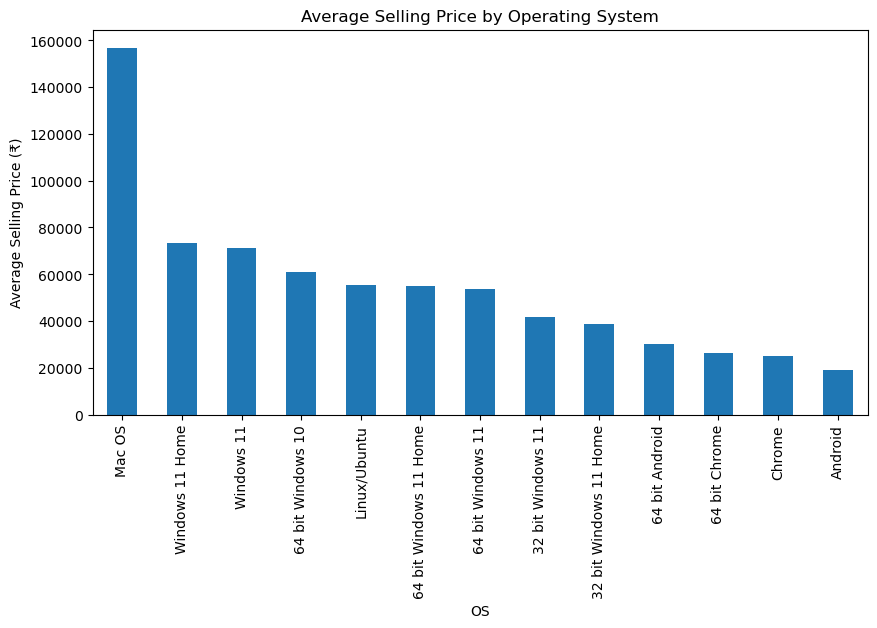

In [78]:
# Average Selling Price by OS

avg_price_os = df.groupby('OS')['Selling_Price'].mean().sort_values(ascending=False)
avg_price_os.plot(kind='bar', figsize=(10,5))
plt.title("Average Selling Price by Operating System")
plt.ylabel("Average Selling Price (₹)")
plt.xlabel("OS")
plt.show()

### Insight
* macOS laptops → highest price
* Windows laptops → moderate price
### Market Insight
* Apple laptops are premium.

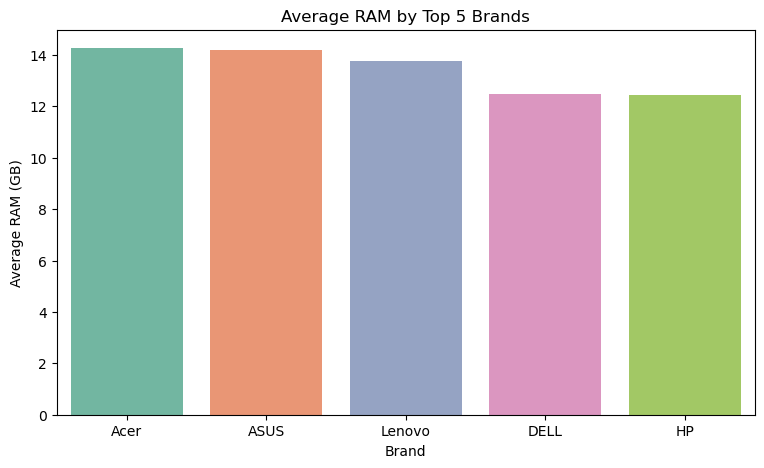

In [79]:
# Average RAM for top 5 brands
avg_ram = df_top5.groupby("Brand")["RAM"].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=avg_ram.index, y=avg_ram.values, palette="Set2")
plt.title("Average RAM by Top 5 Brands")
plt.xlabel("Brand")
plt.ylabel("Average RAM (GB)")
plt.show()

### Insight
* Gaming brands like ASUS offer higher RAM on average.
* Budget brands offer 8–16GB mostly.

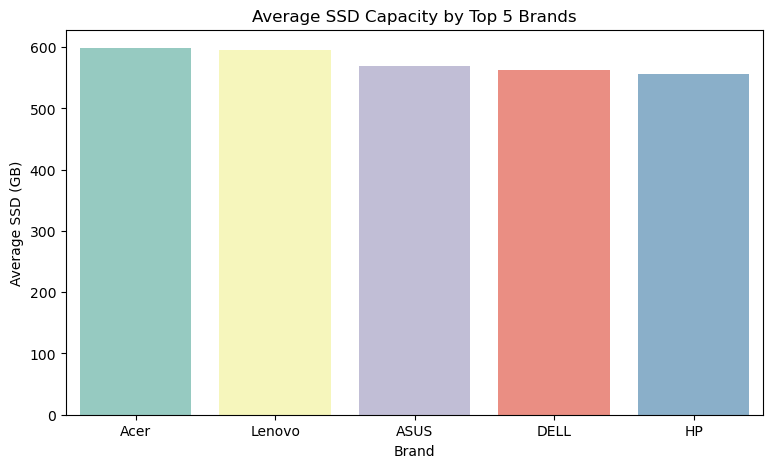

In [80]:
# Average SSD for top 5 brands
avg_ssd = df_top5.groupby("Brand")["SSD_GB"].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=avg_ssd.index, y=avg_ssd.values, palette="Set3")
plt.title("Average SSD Capacity by Top 5 Brands")
plt.xlabel("Brand")
plt.ylabel("Average SSD (GB)")
plt.show()

### Insight
* Top brands increasingly offer 512GB or 1TB SSD.

## Multivariate Anlysis

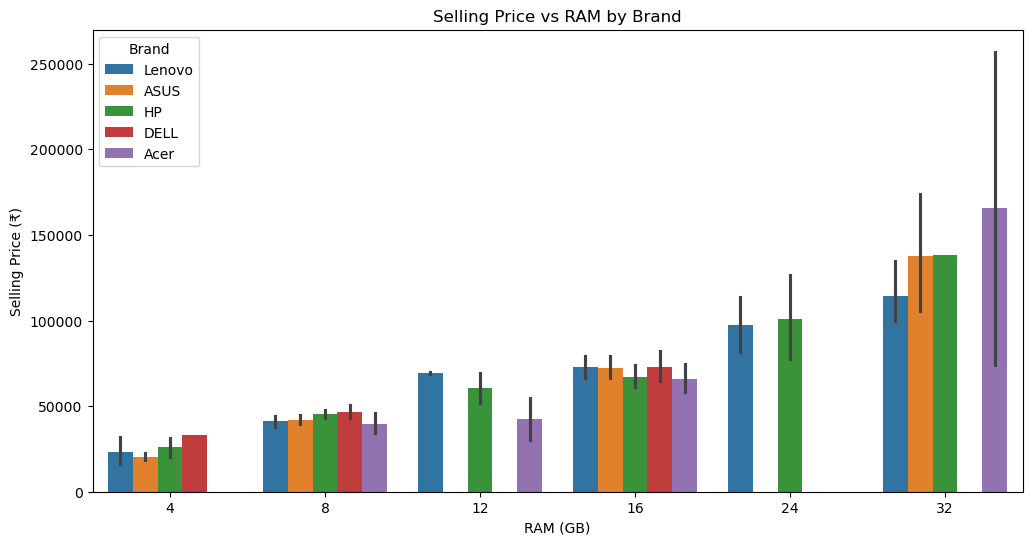

In [81]:
plt.figure(figsize=(12,6))
sns.barplot(x="RAM", y="Selling_Price", hue="Brand",data=df_top5)
plt.title("Selling Price vs RAM by Brand")
plt.xlabel("RAM (GB)")
plt.ylabel("Selling Price (₹)")
plt.show()

### Insight
* Even with the same RAM:
* Apple laptops cost more
* Gaming brands cost more
### Market Insight
* Brand reputation influences price.

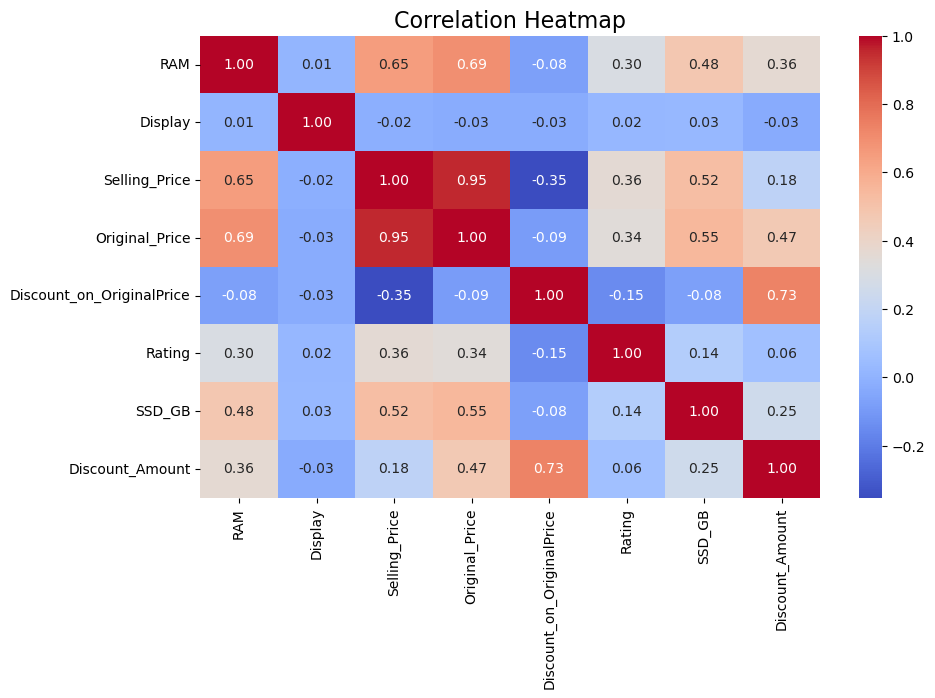

In [82]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

### Key Relationships
| Feature          | Correlation       |
| ---------------- | ----------------- |
| RAM vs Price     | Strong positive   |
| SSD vs Price     | Moderate positive |
| Display vs Price | Weak positive     |
| Rating vs Price  | Very weak         |

### Final Insight
* RAM is the strongest factor affecting laptop price.

## WHY Hypothesis Comes After Visualization?
* Visuals first: Show patterns that “look true” in your data.
* Hypothesis testing next: Confirms whether the patterns are statistically significant.

#### Different data types → Different tests
| Variable Type              | Test Used           |
| -------------------------- | ------------------- |
| Numerical vs Numerical     | Pearson Correlation |
| Categorical vs Numerical   | ANOVA               |
| Categorical vs Categorical | Chi-square          |

### Hypothesis 1: Does Brand influence Laptop Price?
`Categorical vs Numerical → ANOVA)`
* **H₀(Null Hypothesis):** Brand has no impact on laptop price.
* **H₁(Alternative Hypothesis):** Brand affects price.

In [93]:
from scipy.stats import f_oneway

# Group price by Brand
brand_groups = [df[df['Brand'] == value]['Selling_Price'] for value in df['Brand'].unique()]

# Apply ANOVA
f_stat, p_value = f_oneway(*brand_groups)
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H₀ -> Brand affects price")
else:
    print("Fail to reject H₀ -> Brand does not affect price")

F-statistic: 13.161106340432811
P-value: 1.0599391706829868e-32
Reject H₀ -> Brand affects price


#### Observation
* Laptop brand significantly influences selling price.
* Premium brands such as Apple, Dell, and HP generally have higher average prices compared to budget brands.
* This suggests that brand reputation and market positioning play an important role in pricing strategy.

### Hypothesis 2: Processor vs Selling Price
`Categorical vs Numerical → ANOVA`
* **H₀:** Processor type does not influence selling price.
* **H₁:** Processor type significantly influences selling price.

In [84]:
groups = [df[df['Processor']==value]['Selling_Price'] for value in df['Processor'].unique()]

f_stat, p_value = f_oneway(*groups)
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H₀ → Processor significantly affects price")
else:
    print("Fail to reject H₀ → No significant impact")

F-statistic: 50.68983663542531
P-value: 2.6211997910849628e-164
Reject H₀ → Processor significantly affects price


#### Observation
* Processor type has a very strong impact on laptop price.
* Laptops with high-performance processors (Intel i7, Ryzen 7) are priced significantly higher than laptops with entry-level processors (i3, Ryzen 3).
* This shows that CPU performance is one of the main factors determining laptop cost.

### Hypothesis 3: OS vs Selling_Price
`Categorical vs Numerical → ANOVA`
* **H₀:** Operating System (OS) has no impact on laptop price.
* **H₁:** Laptop price differs based on Operating System.

In [85]:
groups = [df[df['OS']==proc]['Selling_Price'] for proc in df['OS'].unique()]

f_stat, p_value = f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H₀ → OS significantly affects price")
else:
    print("Fail to reject H₀ → No significant impact")

F-statistic: 19.629824856181273
p-value: 7.616253444526439e-36
Reject H₀ → OS significantly affects price


### Observation
* Operating system significantly influences laptop pricing.
* Devices running macOS typically have higher prices compared to Windows or other operating systems, reflecting Apple's premium product positioning.
* Therefore, OS choice is indirectly linked to price through the brand ecosystem and hardware quality.

### Hypothesis Test4: Does RAM affect laptop price?
`Discrete vs Numerical → ANOVA`
* **H₀(Null Hypothesis):** RAM has no impact on laptop price
* **H₁(Alternative Hypothesis):** RAM affects laptop price

In [99]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["RAM"], df["Selling_Price"])
print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: RAM has significant impact on Selling Price")
else:
    print("Fail to reject H0: RAM has no significant impact on Selling Price")

Correlation: 0.6484634878443511
P-value: 1.9903329007203843e-69
Reject H0: RAM has significant impact on Selling Price


#### Observation
* RAM capacity significantly affects laptop prices.
* Laptops with higher RAM (16GB or 32GB) tend to have higher selling prices compared to laptops with lower RAM (4GB or 8GB).
* This indicates that memory capacity strongly contributes to laptop performance and price differentiation.

### Hypothesis 5: Does SSD Size affect Laptop Price?
* H0: SSD size has no relationship with laptop price
* H1: SSD size has a relationship with laptop price

In [88]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["SSD_GB"], df["Selling_Price"])
print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: SSD size significantly affects laptop price")
else:
    print("Fail to reject H0: No significant relationship")

Correlation: 0.5244013931791839
P-value: 1.1728736334059738e-41
Reject H0: SSD size significantly affects laptop price


### Observation
* There is a moderate positive relationship between SSD capacity and laptop price.
* As SSD size increases, the selling price of laptops also tends to increase.
* This suggests that storage capacity contributes to overall laptop value and pricing.

### Hypothesis 6: Rating vs Selling Price
`Numerical vs Numerical → Pearson Correlation.`
* H₀: Customer ratings have no relationship with laptop price.
* H₁: Higher ratings are associated with higher price.

In [89]:
corr, p_value = pearsonr(df['Rating'], df['Selling_Price'])
print("Correlation:", corr)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H₀ → Rating significantly affects price")
else:
    print("Fail to reject H₀ → No significant impact")

Correlation: 0.36040052317206206
p-value: 5.9089423205065415e-19
Reject H₀ → Rating significantly affects price


#### Observation:
* Most laptops have ratings 4–4.5 stars
* Weak positive correlation between rating and price.
* Higher-rated laptops are slightly more expensive.
* Business Insight: Ratings alone are not reliable for pricing decisions.

### Hypothesis 7: Is there a relationship between Discount and Rating?
* H0: Discount does not affect ratings.
* H1: Discount affects ratings.

In [90]:
corr, p_value = pearsonr(df["Discount_on_OriginalPrice"], df["Rating"])
print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Discount significantly relates to rating")
else:
    print("No significant relationship")

Correlation: -0.14784061735495033
P-value: 0.000393365403256646
Reject H0: Discount significantly relates to rating


#### Observation
* There is a weak negative relationship between discount percentage and rating.
* Products with higher discounts sometimes have slightly lower ratings, possibly because discounts are offered to boost sales of less popular models.

### Hypothesis 8 : Display Size vs Selling Price
* H₀: Display size does not affect laptop price
* H₁: Display size affects laptop price

In [91]:
corr, p_value = pearsonr(df["Display"], df["Selling_Price"])

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Display size significantly affects laptop price")
else:
    print("Fail to reject H0: Display size does not significantly affect laptop price")

Correlation: -0.016849072625442055
P-value: 0.6878569473891811
Fail to reject H0: Display size does not significantly affect laptop price


### Hypothesis 9: Discount vs Selling Price
* H₀ (Null Hypothesis): Discount has no relationship with laptop selling price.
* H₁ (Alternative Hypothesis): Discount has a relationship with laptop selling price.

In [92]:
corr, p_value = pearsonr(df["Discount_on_OriginalPrice"], df["Selling_Price"])

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Discount significantly relates to laptop price")
else:
    print("Fail to reject H0: Discount does not significantly relate to laptop price")

Correlation: -0.3523516110811541
P-value: 3.9177124269573886e-18
Reject H0: Discount significantly relates to laptop price


### Selling Price Analysis
* Selling_Price is right-skewed
* A few very expensive laptops (₹1,20,000 – ₹2,00,000) pull the mean up
* Median Selling Price ≈ ₹58,000
* Mean Selling Price ≈ ₹72,000

#### Interpretation
* Most laptops are priced in the ₹50,000 – ₹80,000 range
* Mean price is slightly misleading due to premium laptops
* Mid-range laptops dominate the dataset

#### Market Insight
* High-priced laptops are fewer but increase the overall average
* The strongest market segment lies between ₹50K–₹80K

### Processor Analysis
* Most laptops have mid-range processors
* Price increases clearly with processor category
Example pattern:
    * i3 laptops ≈ ₹35,000 – ₹45,000
    * i5 laptops ≈ ₹50,000 – ₹75,000
    * i7 laptops ≈ ₹80,000 – ₹1,20,000

#### Interpretation
* Processor is one of the strongest price drivers
* Higher processor category significantly increases price

#### Market Insight
* Mid-level processors dominate the dataset
* High-end processors form premium segment

### RAM Analysis
* Most laptops have:
    * 8 GB RAM (majority)
    * 16 GB RAM (second highest)
* Price difference:
    * 8 GB laptops ≈ ₹45,000 – ₹65,000
    * 16 GB laptops ≈ ₹65,000 – ₹95,000
    * 32 GB laptops > ₹1,10,000

#### Interpretation
* Selling_Price increases as RAM increases
* 8 GB is standard
* 16 GB is performance segment

#### Market Insight
* RAM strongly affects laptop pricing
* 16 GB models are positioned as premium

### SSD (Storage) Analysis
* Most laptops have 512 GB SSD
* Price difference:
    * 256 GB ≈ ₹40,000 – ₹55,000
    * 512 GB ≈ ₹55,000 – ₹85,000
    * 1 TB ≈ ₹80,000 – ₹1,10,000

#### Interpretation
* SSD capacity increases price moderately
* After 512 GB, price rise is not as sharp

#### Market Insight
* 512 GB SSD is the most common configuration
* Higher SSD increases price but not as strongly as processor or RAM

### Rating Analysis
* Ratings mostly lie between 4.0 – 4.5
* Very little variation
* Weak relationship between Rating and Selling_Price
* Example:
    * ₹55,000 laptop rating ≈ 4.3
    * ₹1,20,000 laptop rating ≈ 4.4

#### Interpretation
* Higher-rated laptops are not always more expensive
* Rating is not a strong pricing factor

### Discount Analysis
* Original_Price is higher than Selling_Price
* Average discount ≈ ₹8,000 – ₹20,000
* Higher-priced laptops show larger discount amounts
* Example:
    * Original: ₹95,000
    * Selling: ₹78,000
    * Discount ≈ ₹17,000

#### Interpretation
* Discount is a marketing strategy
* Final Selling_Price depends mainly on specifications

### Bivariate & Multivariate EDA – Key Learnings Insights
* Strong relationship: Price ↔ RAM, SSD, Processor
* Weak relationship: Price ↔ Rating
* Brand-based price clusters visible
* Conclusion: Technical specifications drive laptop pricing more than ratings or display size

### Correlation Insights
* Stronger correlation:
    * Selling_Price ↔ RAM
    * Selling_Price ↔ Processor
    * Selling_Price ↔ SSD
* Weak correlation:
    * Selling_Price ↔ Rating
    * Selling_Price ↔ Display

### Final Recommendations for Laptop Buyers
1. Target price range: ₹50,000–₹75,000 (mid-range)
2. RAM: 8–16 GB
3. SSD: 256–512 GB
4. Processor: i5/Ryzen 5 for budget; i7/Ryzen 7 for premium
5. Rating: Minor differences, ignore for pricing decision
6. Avoid paying extra for specs beyond daily use needs

### Conclusion:
* Mid-range laptops offer the best value
* Laptop pricing is primarily driven by:
    * Processor
    * RAM
    * SSD
* The most common configuration observed:
    * ₹55,000 – ₹75,000
    * Mid-level Processor
    * 8–16 GB RAM
    * 512 GB SSD

Premium configurations significantly increase price, but represent a smaller portion of the market.